In [16]:
# CIL optimisation algorithms and linear operators
from cil.optimisation.algorithms import  FISTA, HybridGLSQR, GLSQR
from cil.optimisation.utilities.HybridUpdateReg import UpdateRegDiscrep, UpdateRegGCV, UpdateRegLcurve, UpdateRegReginska, UpdateRegUPRE
from cil.optimisation.operators import WaveletOperator, GradientOperator
# Third-party imports
import numpy as np
from time import time    

# CIL imports for data loading and visualisation
from cil.utilities.display import show2D

import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.info("test")

## Load Data
In this example, we utilize CIL's simulated sphere data. To accelerate computations in this notebook, we extract a 2D slice from the 3D dataset. Additionally, we select a subset of angles to create a limited-angle reconstruction scenario. We will then compare the ground truth data with a filtered back projection (FBP) reconstruction under these limited-angle conditions.

FDK recon

Input Data:
	angle: 60
	horizontal: 128

Reconstruction Volume:
	horizontal_y: 128
	horizontal_x: 128

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 8
	Filter_inplace: False



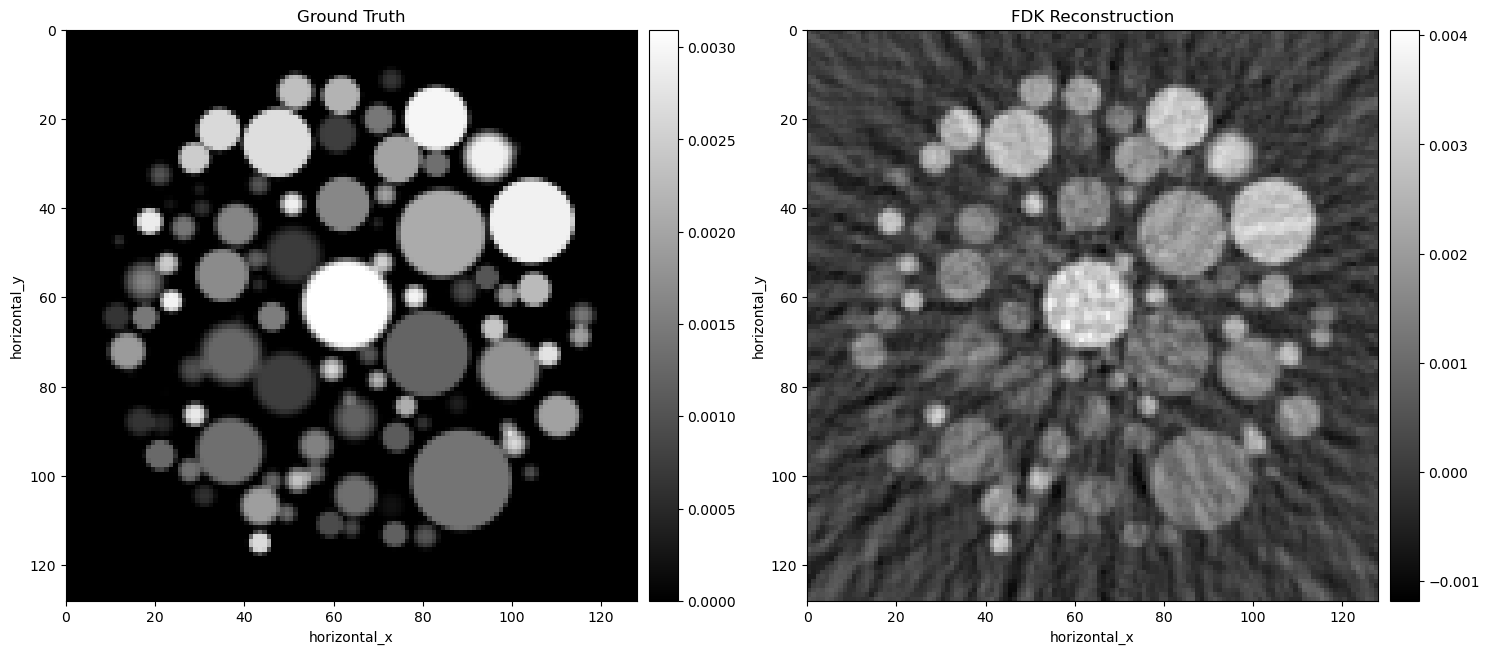

Inverse error from wavelet coefficients:  2.1152204e-07


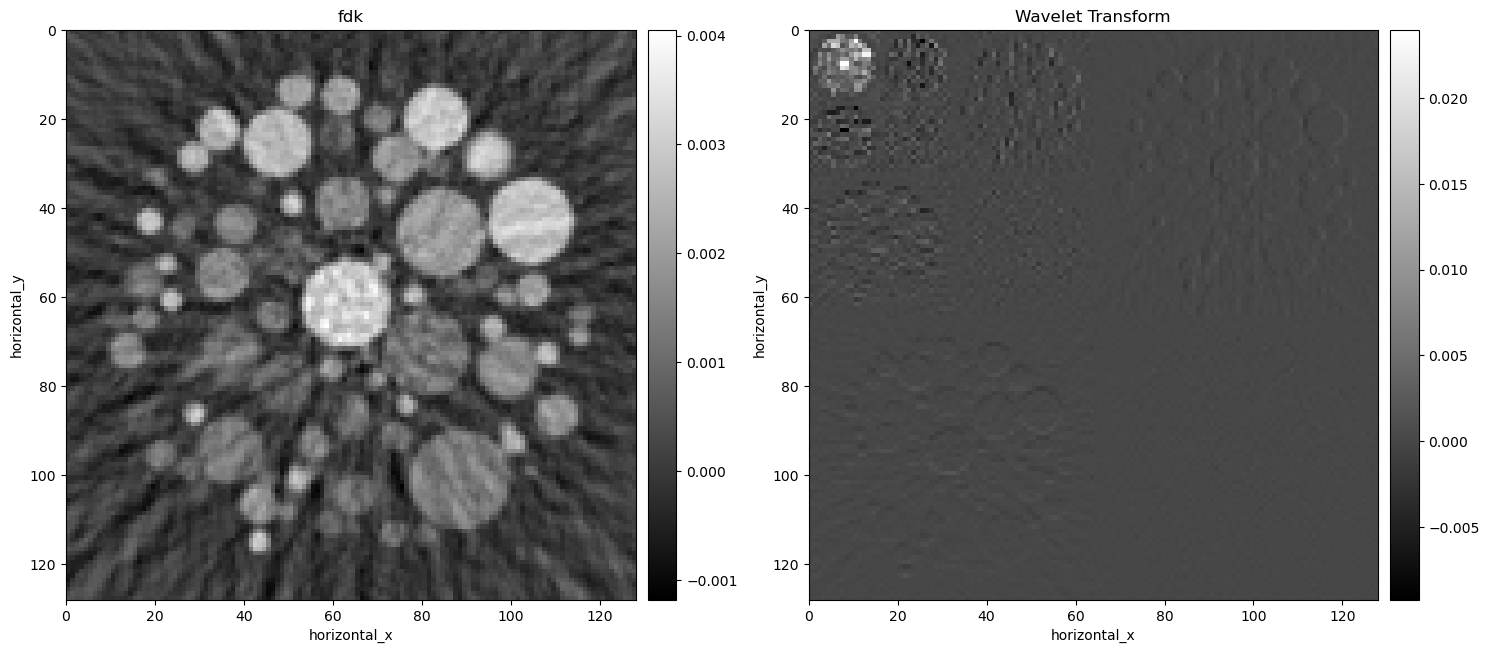

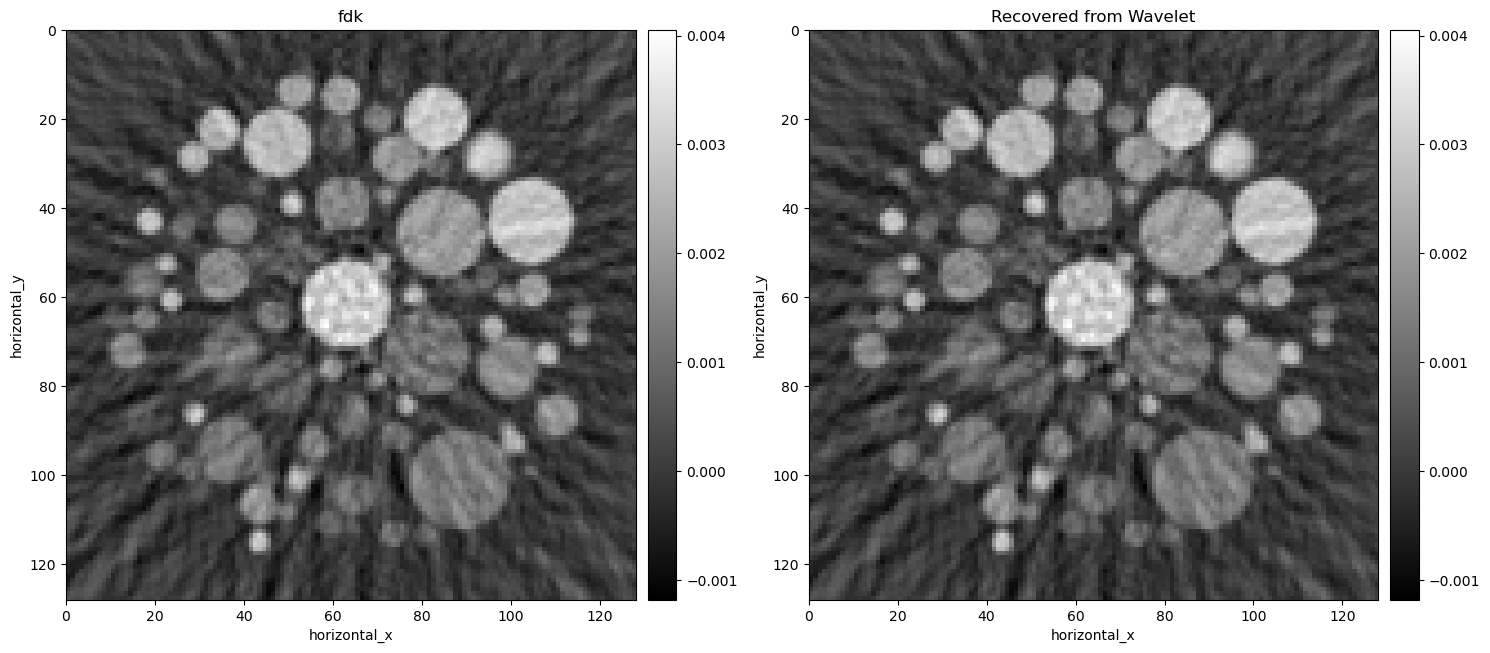

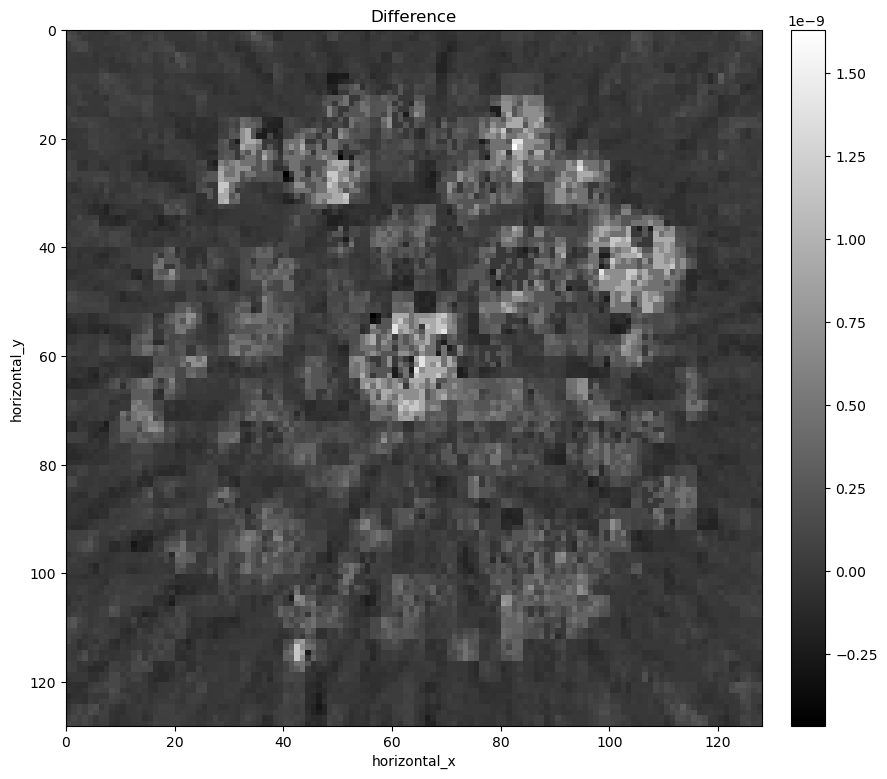

In [17]:
from data_loader import load_and_process_sphere

# Load data
data, A, ig, ground_truth, fdk = load_and_process_sphere(angle_step=5,single_slice=True)

# Set up Initial
initial = A.domain_geometry().allocate(0)
 
# Create Wavelet operator for 3D data
W = WaveletOperator(ig, wavelet='db2', level=3)
fdk_wavelet=W.direct(fdk)
recovered_fdk_wavelet=W.inverse(fdk_wavelet)
diff = fdk - recovered_fdk_wavelet
print("Inverse error from wavelet coefficients: ", np.linalg.norm(diff.as_array())/np.linalg.norm(fdk.as_array()))
show2D([fdk, fdk_wavelet], title = ['fdk', 'Wavelet Transform'], origin = 'upper', num_cols = 2)
show2D([fdk, recovered_fdk_wavelet], title = ['fdk', 'Recovered from Wavelet'], origin = 'upper', num_cols = 2)
show2D([diff], title = ['Difference'], origin = 'upper', num_cols = 1)

## Hybrid methods in action L1 Regularization

1. Discrepency
2. GCV
3. Weighted GCV
4. Adaptive Weighted GCV
5. Reginska
6. UPRE
7. L-curve


In [18]:
# We set a tolerance, an initial guess, and a maximum number of iterations
alpha_tol = 1e-3
maxit = 10
xtol = 1e-6
max_inner_iterations = 50

# Define noise level
noise_std = 0.1 * np.std(data.array) 
noiselevel = 0.03 * np.linalg.norm(data.array)
noisevariance = noise_std**2

norm_type = 'L1'

def results_and_rerun(hybridlsqr):
    print("The optimal parameter it finds is", hybridlsqr.regalpha, "in", hybridlsqr.iteration, "iterations")

    hybridlsqr.reg_rule.plot_function()
    try:  
        hybridlsqr.reg_rule.plot_history()
    except:
        pass

    show2D([ground_truth, hybridlsqr.solution],
        title = ['Ground Truth', f"{hybridlsqr.reg_rule.rule_type} \n Optimal alpha: {hybridlsqr.regalpha:.2e}"],
        origin = 'upper', num_cols = 2)
    show2D([ground_truth, hybridlsqr.x],
        title = ['Ground Truth', f"{hybridlsqr.reg_rule.rule_type} \n Optimal alpha: {hybridlsqr.regalpha:.2e}"],
        origin = 'upper', num_cols = 2)
    
    # Rerun GLSQR with the optimal alpha found by HybridLSQR
    inner_its = hybridlsqr.total_iterations // hybridlsqr.iteration
    lsqr = GLSQR(operator=A, data=data, initial=initial,
                            struct_operator=W, max_inner_iterations=inner_its,
                            reg_norm_type=norm_type, regalpha=hybridlsqr.regalpha)
    lsqr.run(hybridlsqr.reg_rule.iteration, verbose=True)
    show2D([ground_truth, lsqr.solution],
        title = ['Ground Truth', f"{hybridlsqr.reg_rule.rule_type} \n Optimal alpha: {lsqr.regalpha:.2e}"],
        origin = 'upper', num_cols = 2)
    show2D([ground_truth, lsqr.x],
        title = ['Ground Truth', f"{hybridlsqr.reg_rule.rule_type} \n Optimal alpha: {lsqr.regalpha:.2e}"],
        origin = 'upper', num_cols = 2)

## 1. Discrepency Rule

In [19]:
discrep_rule = UpdateRegDiscrep(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                noise_level_estimate=noiselevel)

hybridlsqrD = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                          struct_operator=W, max_inner_iterations=max_inner_iterations,
                          reg_norm_type=norm_type, hybrid_reg_rule=discrep_rule)
t_start = time()
hybridlsqrD.run(maxit, verbose=True)
t_end = time()
print(f"Discrepancy rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

Discrepancy rule took 10.003478288650513 seconds.


The optimal parameter it finds is 3.308719438061636 in 10 iterations


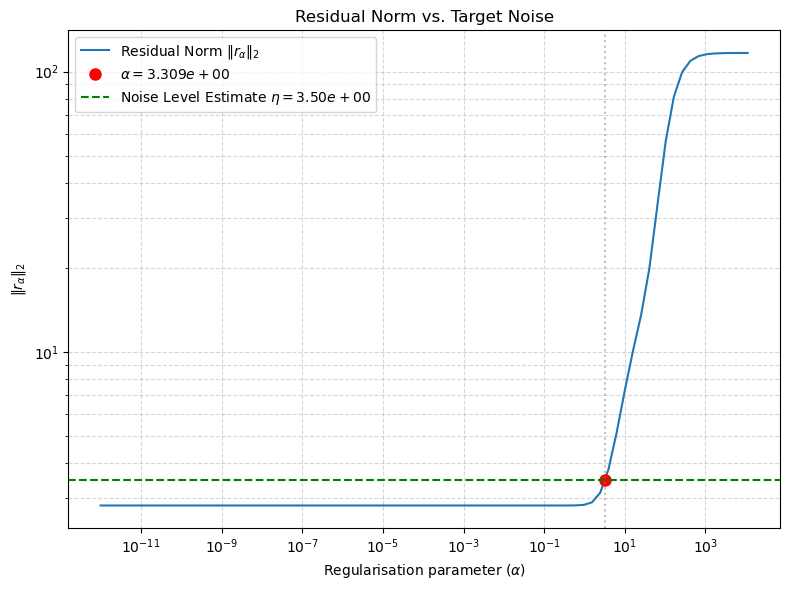

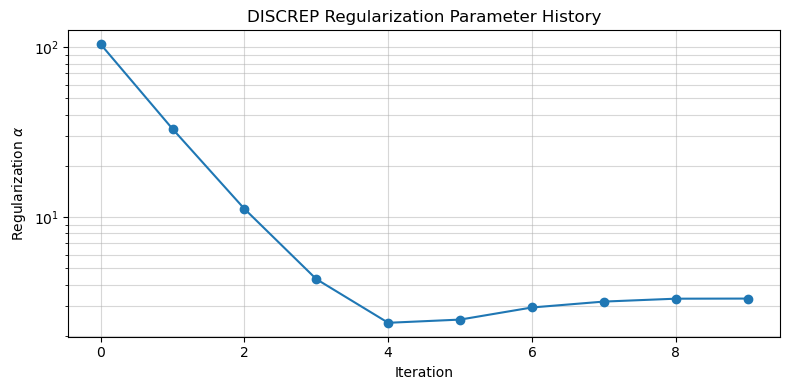

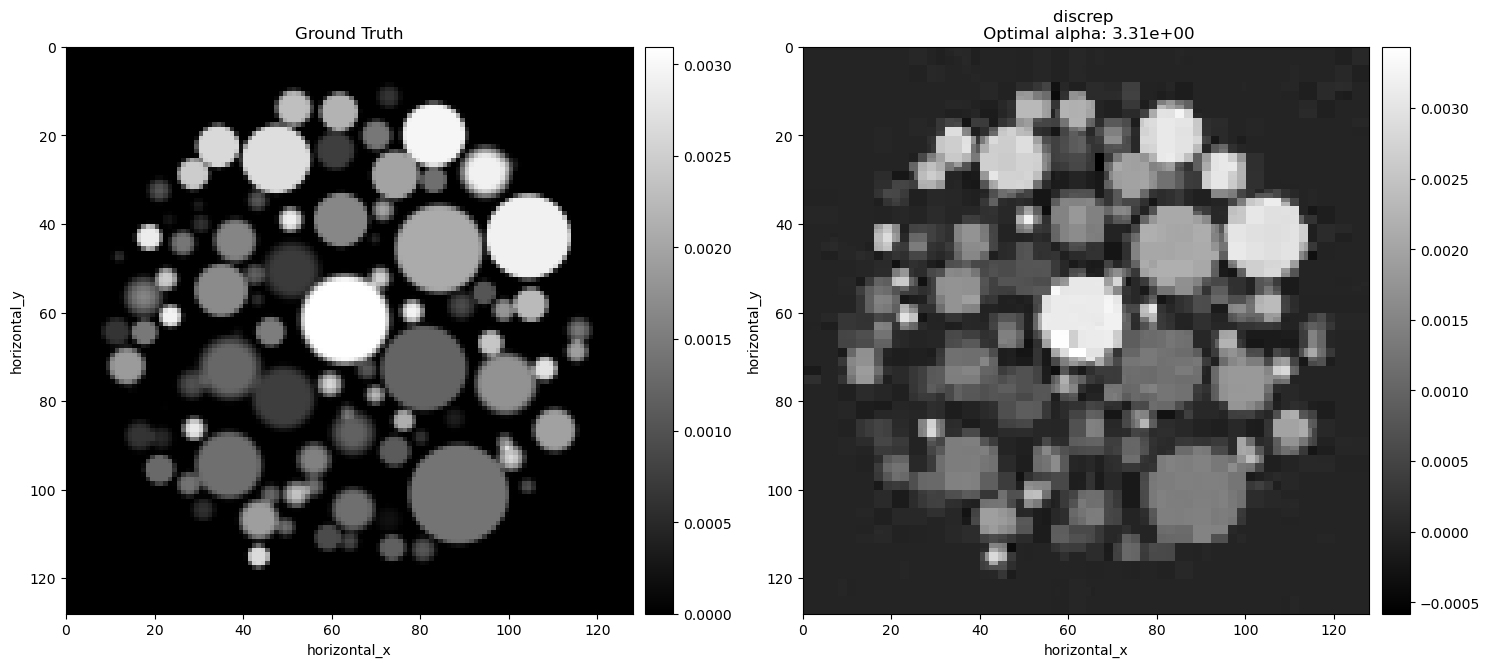

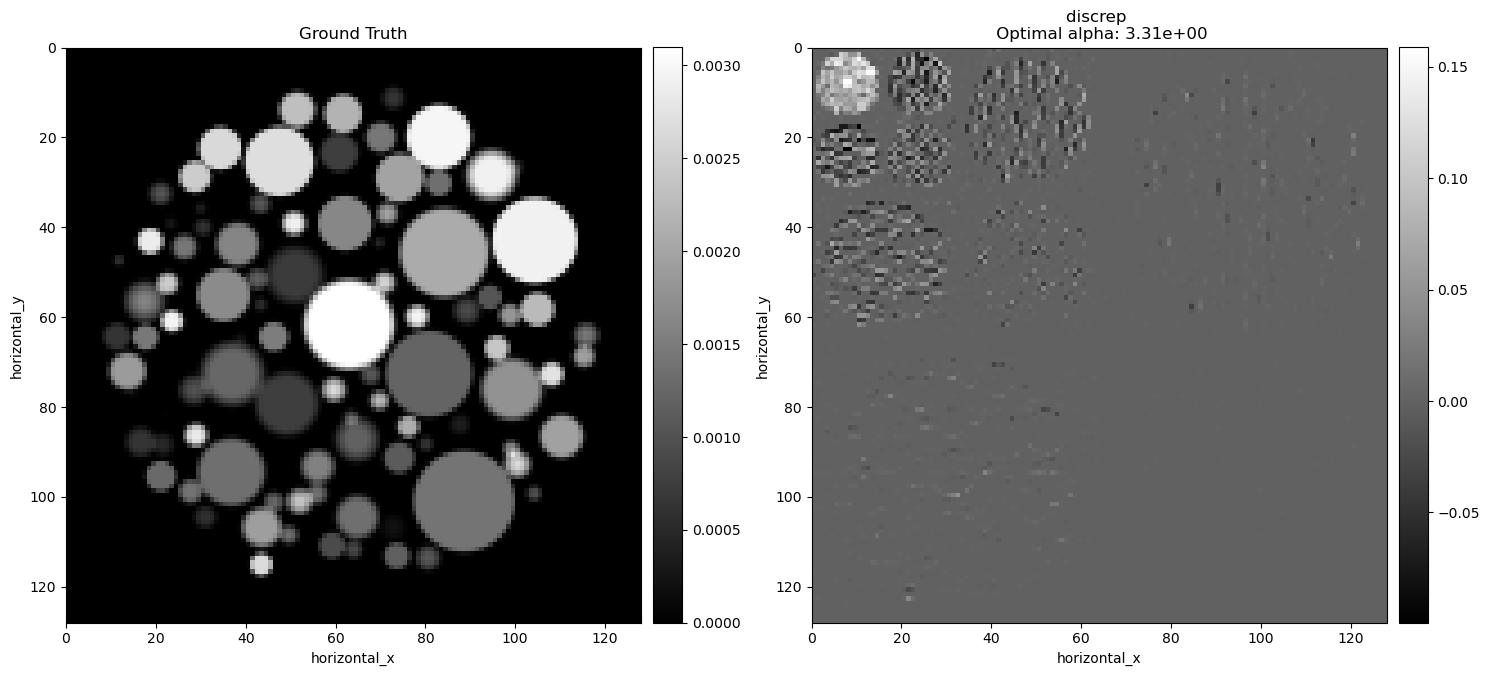

  0%|          | 0/10 [00:00<?, ?it/s]

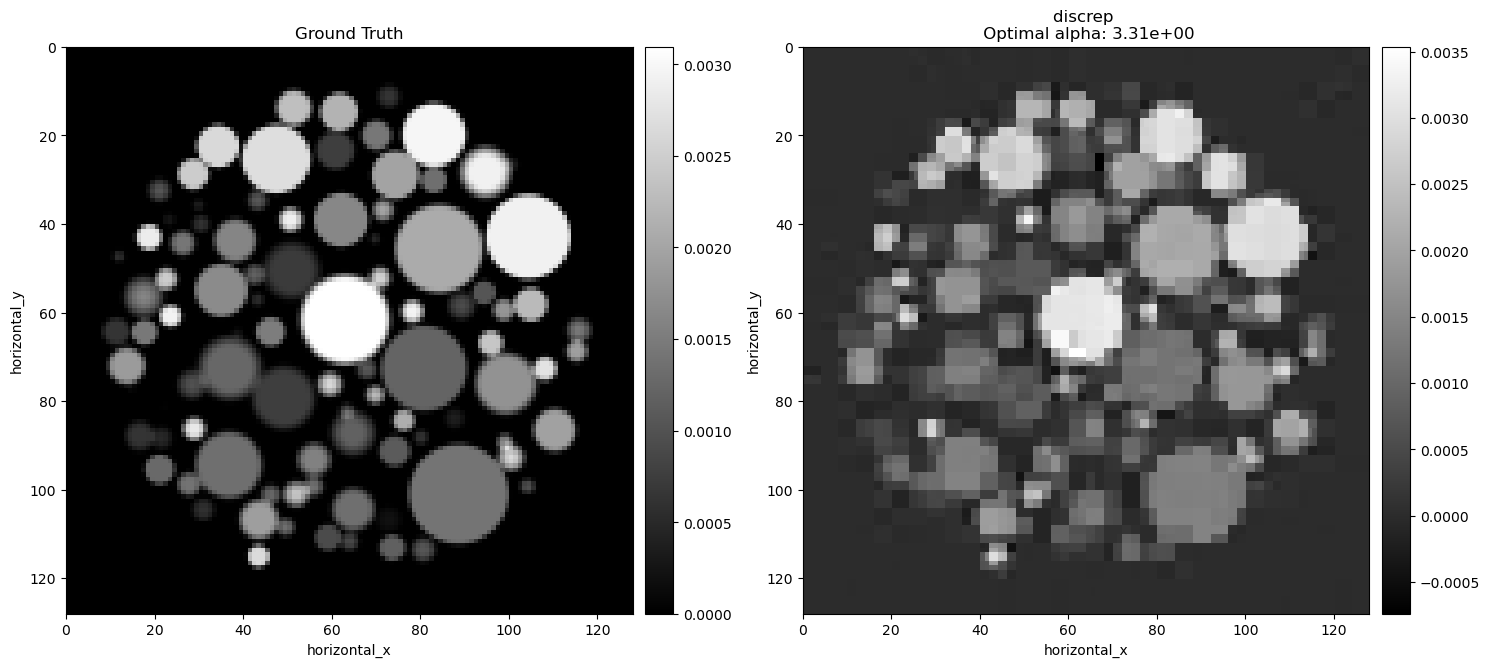

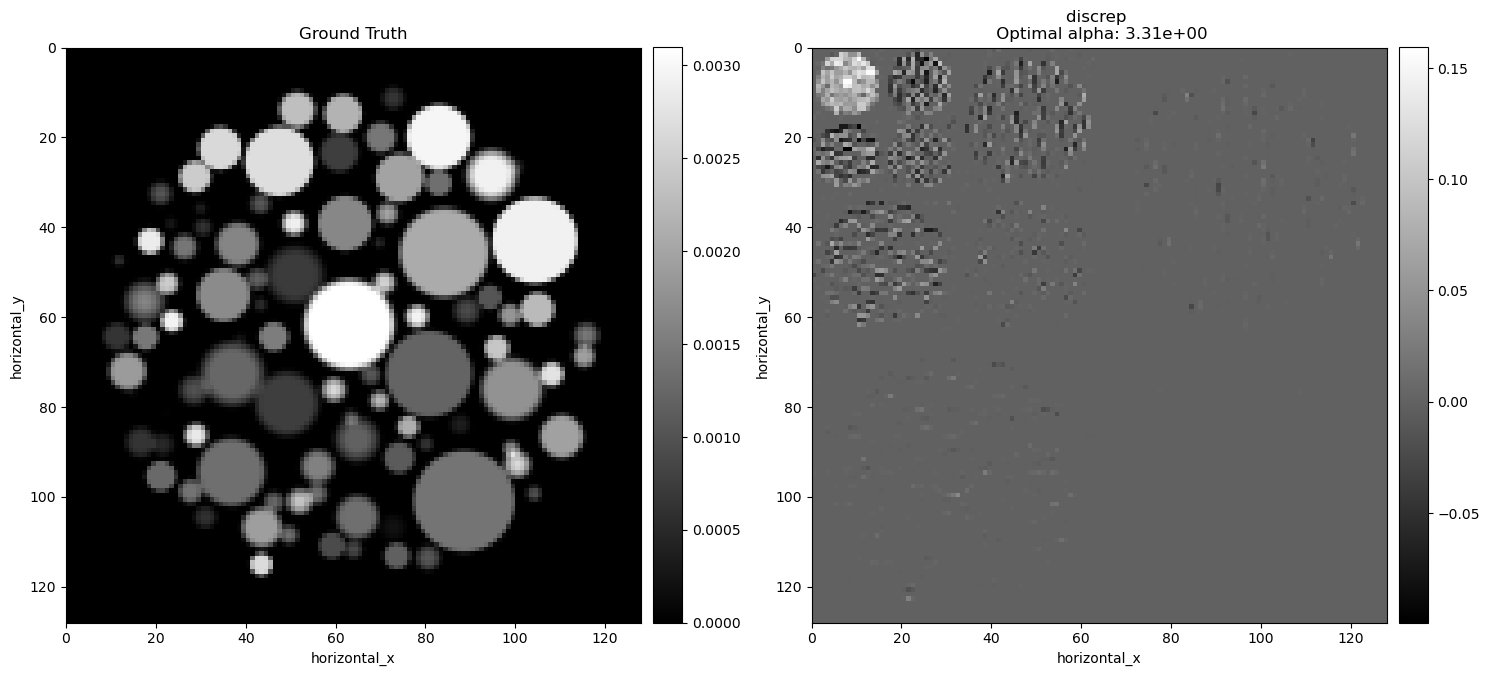

In [20]:
results_and_rerun(hybridlsqrD)

## 2. Standard GCV Rule

In [21]:
gcv_rule = UpdateRegGCV(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                adaptive_weight=False)

hybridlsqrgcv = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                           struct_operator=W, max_inner_iterations=max_inner_iterations,
                         reg_norm_type=norm_type, hybrid_reg_rule=gcv_rule)
t_start = time()
hybridlsqrgcv.run(maxit, verbose=True)
t_end = time()
print(f"GCV rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

GCV rule took 2.9356472492218018 seconds.


The optimal parameter it finds is 26.92322370505584 in 6 iterations


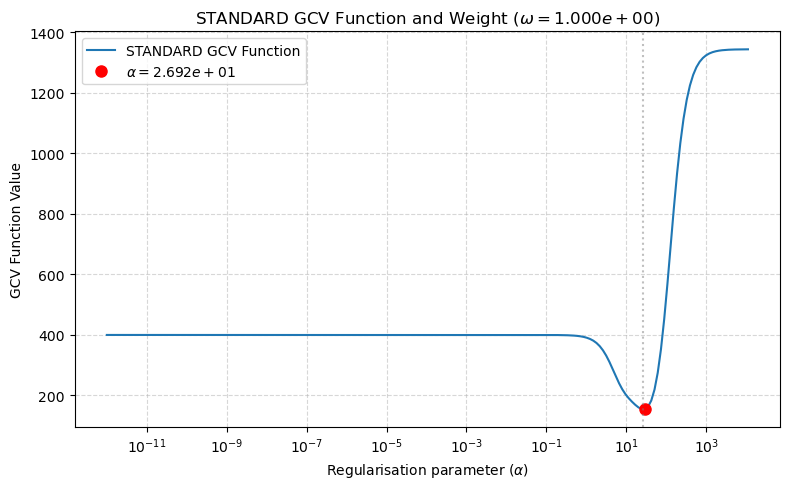

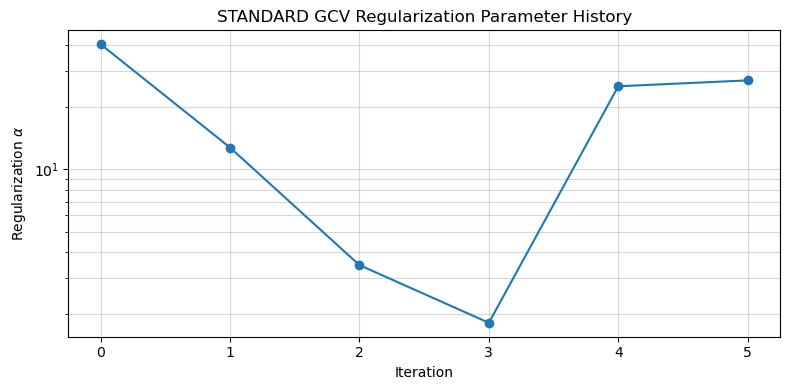

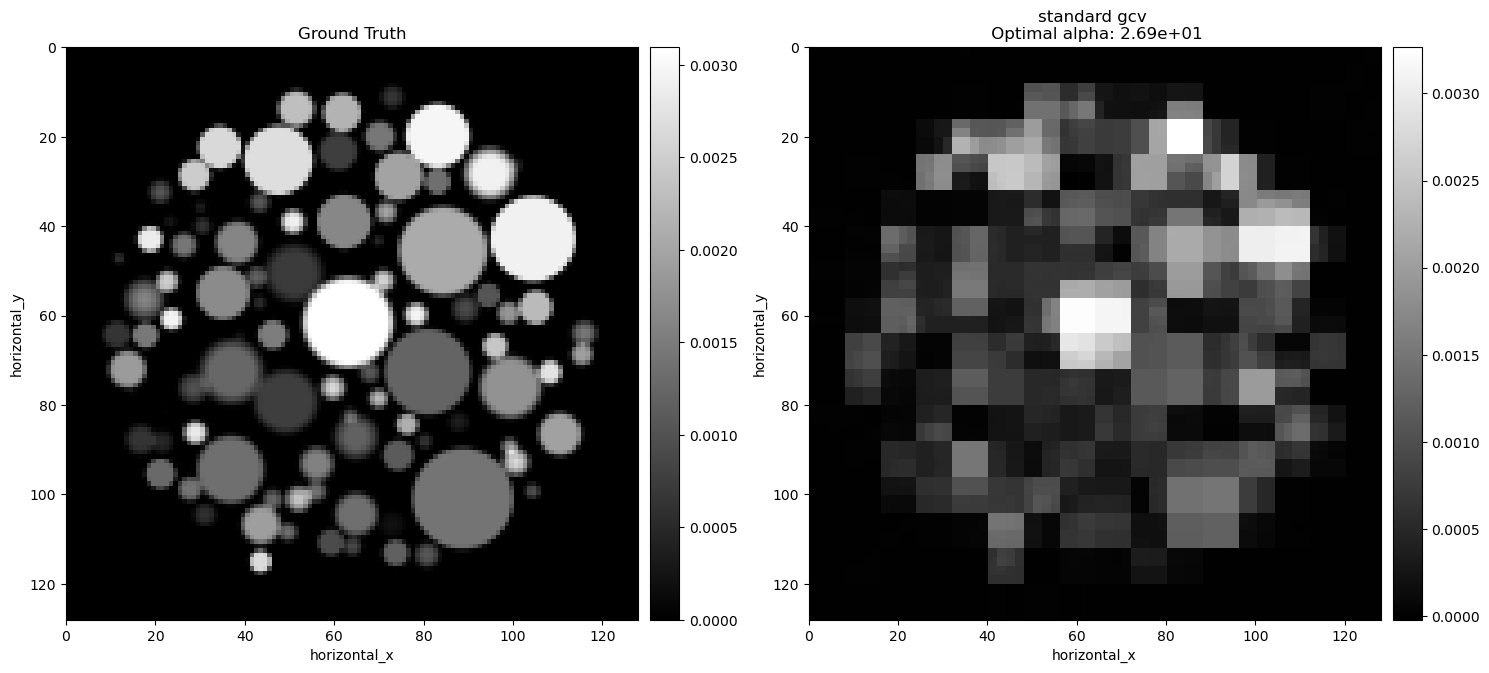

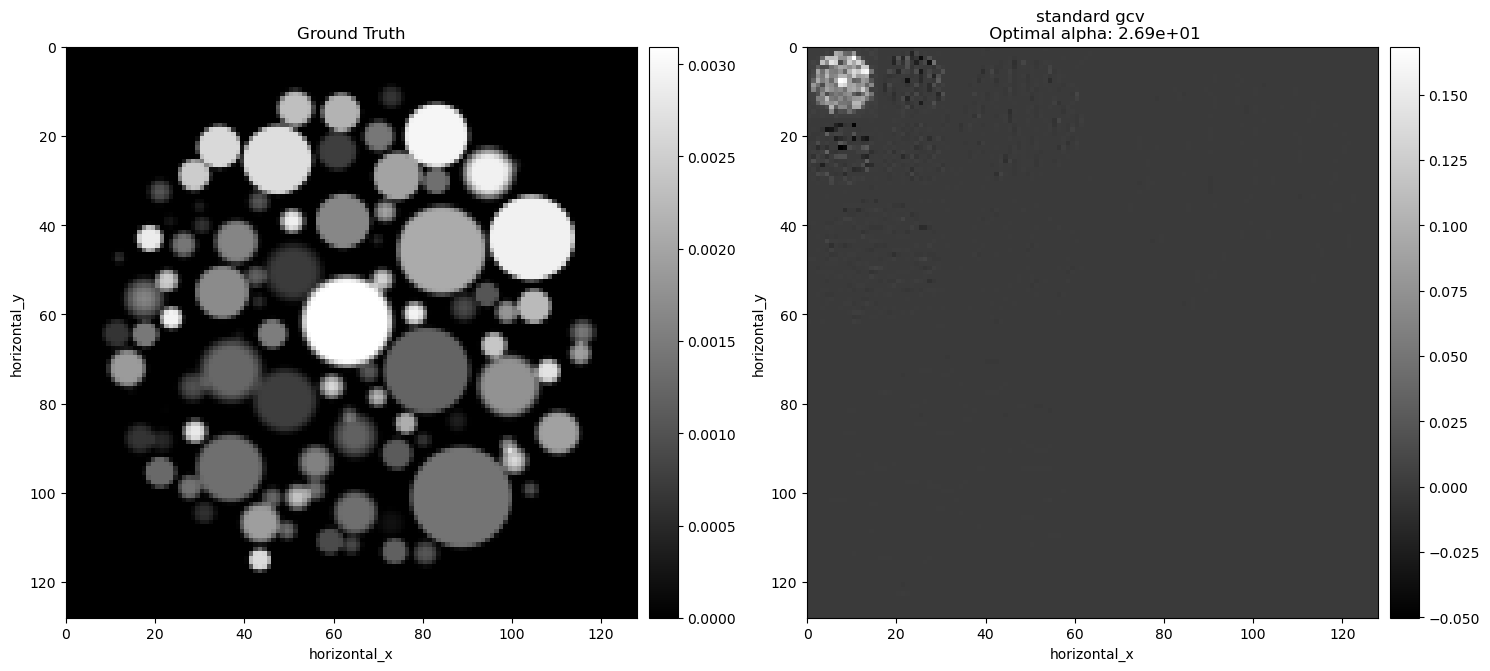

  0%|          | 0/6 [00:00<?, ?it/s]

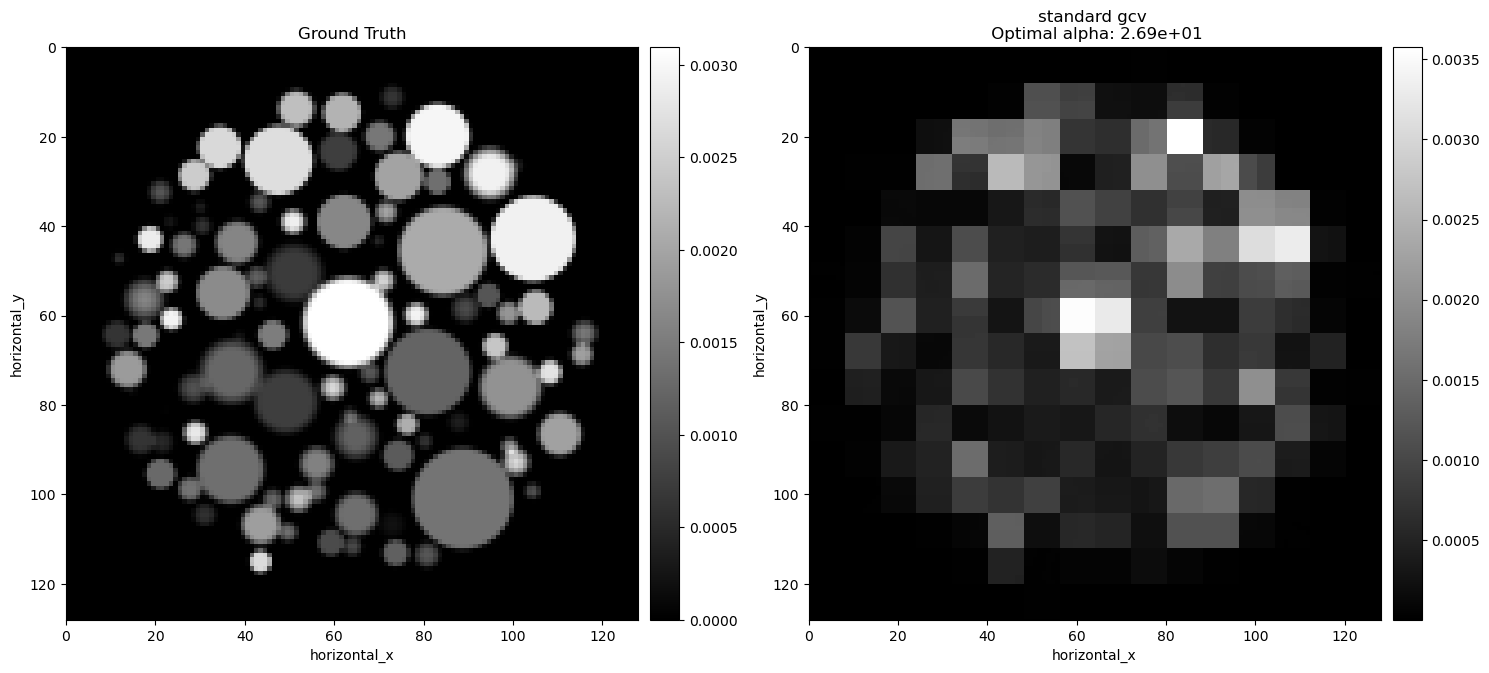

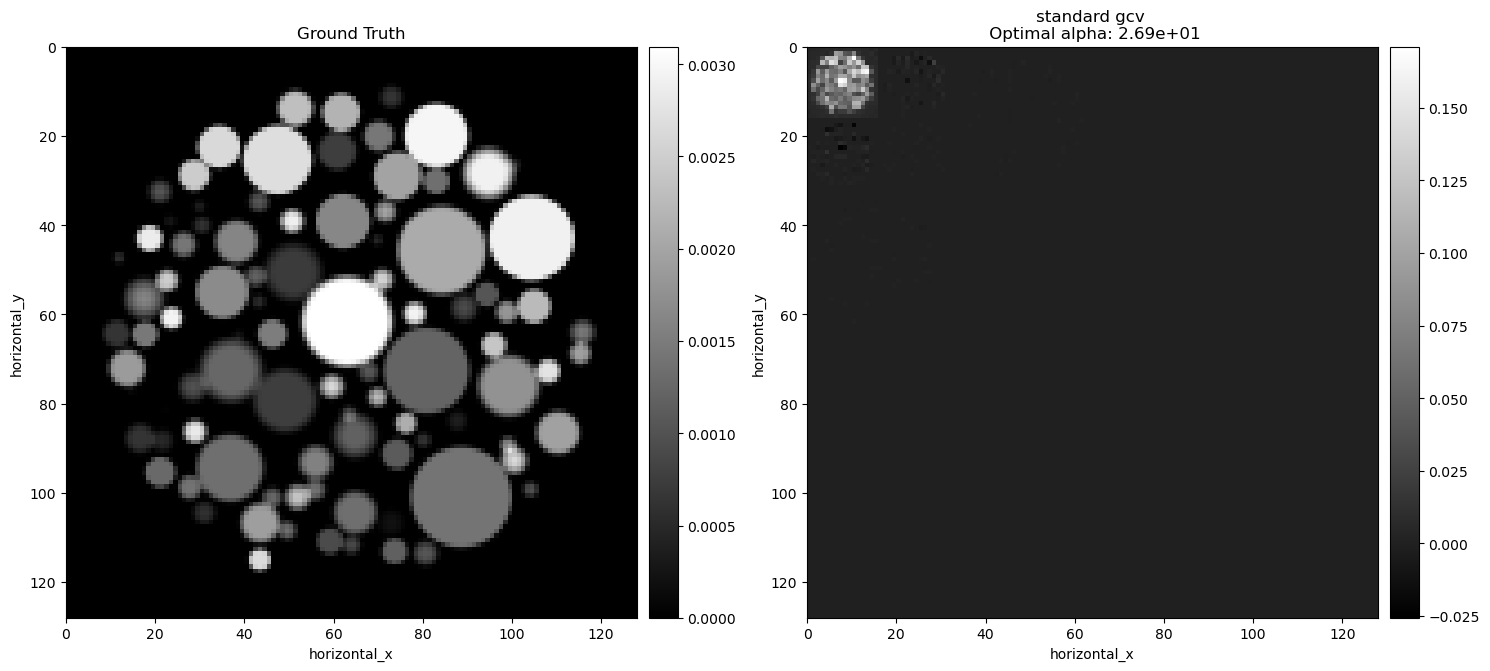

In [22]:
results_and_rerun(hybridlsqrgcv)

## 3. Weighted GCV Rule

In [23]:
wgcv_rule = UpdateRegGCV(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                gcv_weight=0.7,
                                adaptive_weight=False)

hybridlsqrwgcv = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                            struct_operator=W, max_inner_iterations=max_inner_iterations,
                         reg_norm_type=norm_type, hybrid_reg_rule=wgcv_rule)
t_start = time()
hybridlsqrwgcv.run(maxit, verbose=True)
t_end = time()
print(f"WGCV rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

WGCV rule took 3.123664140701294 seconds.


The optimal parameter it finds is 5.368773303032752 in 6 iterations


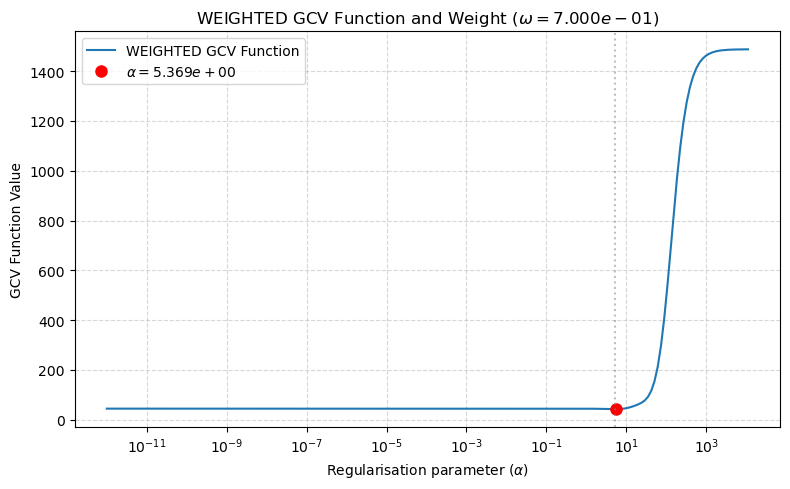

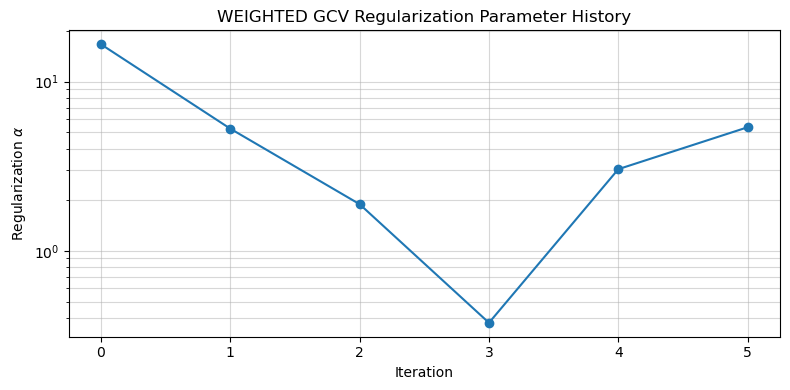

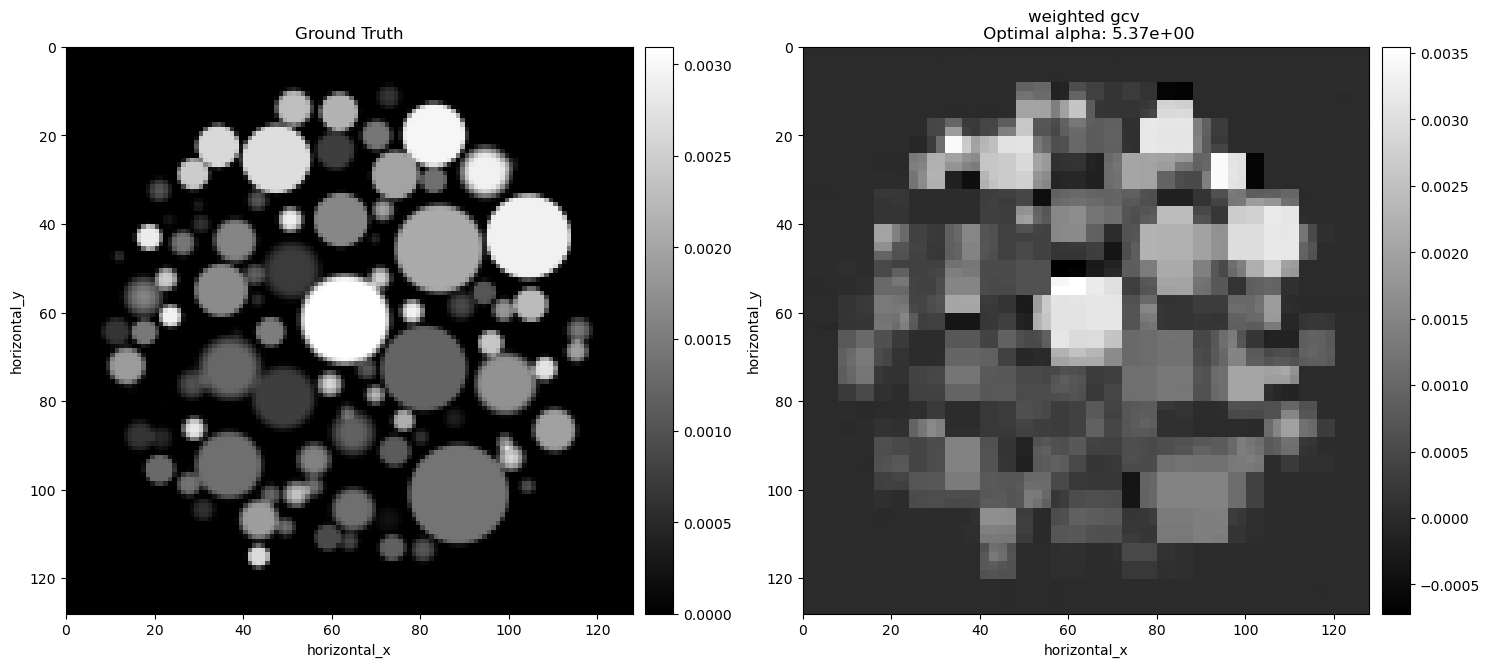

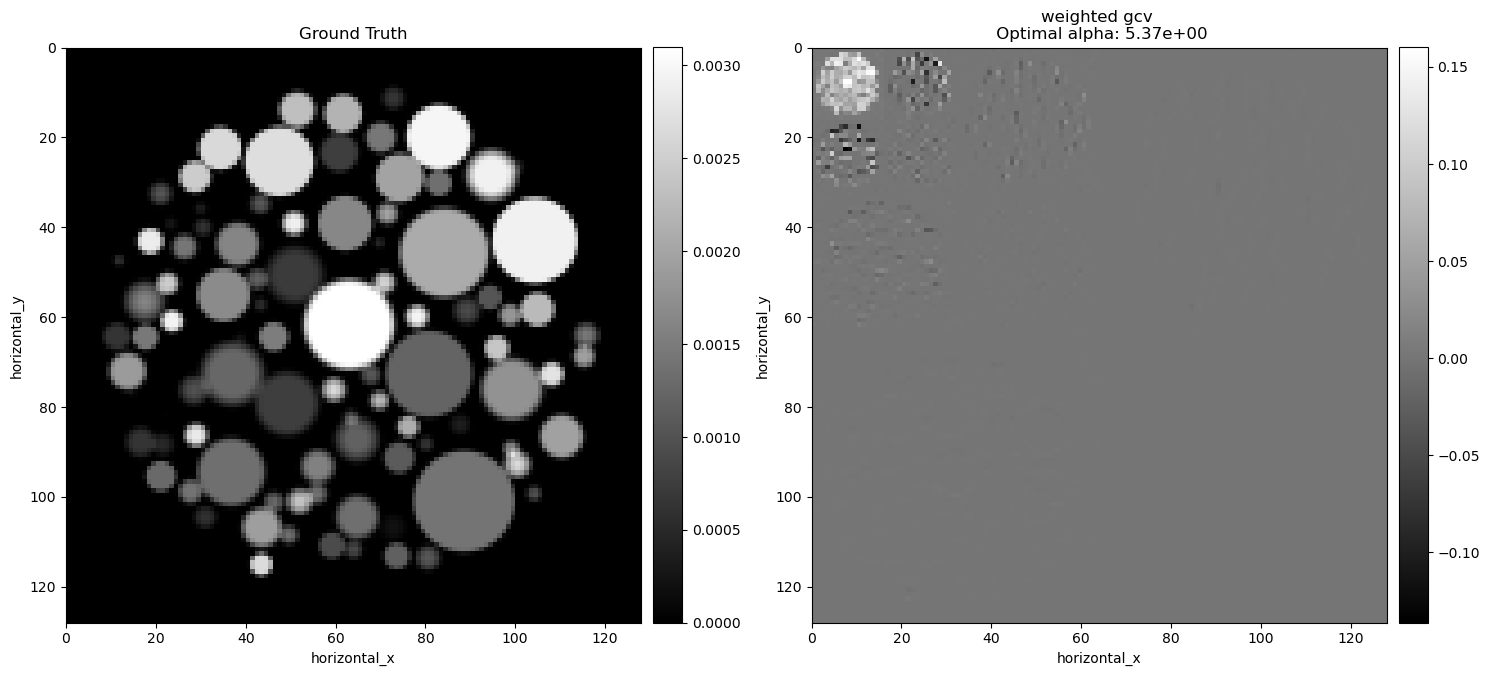

  0%|          | 0/6 [00:00<?, ?it/s]

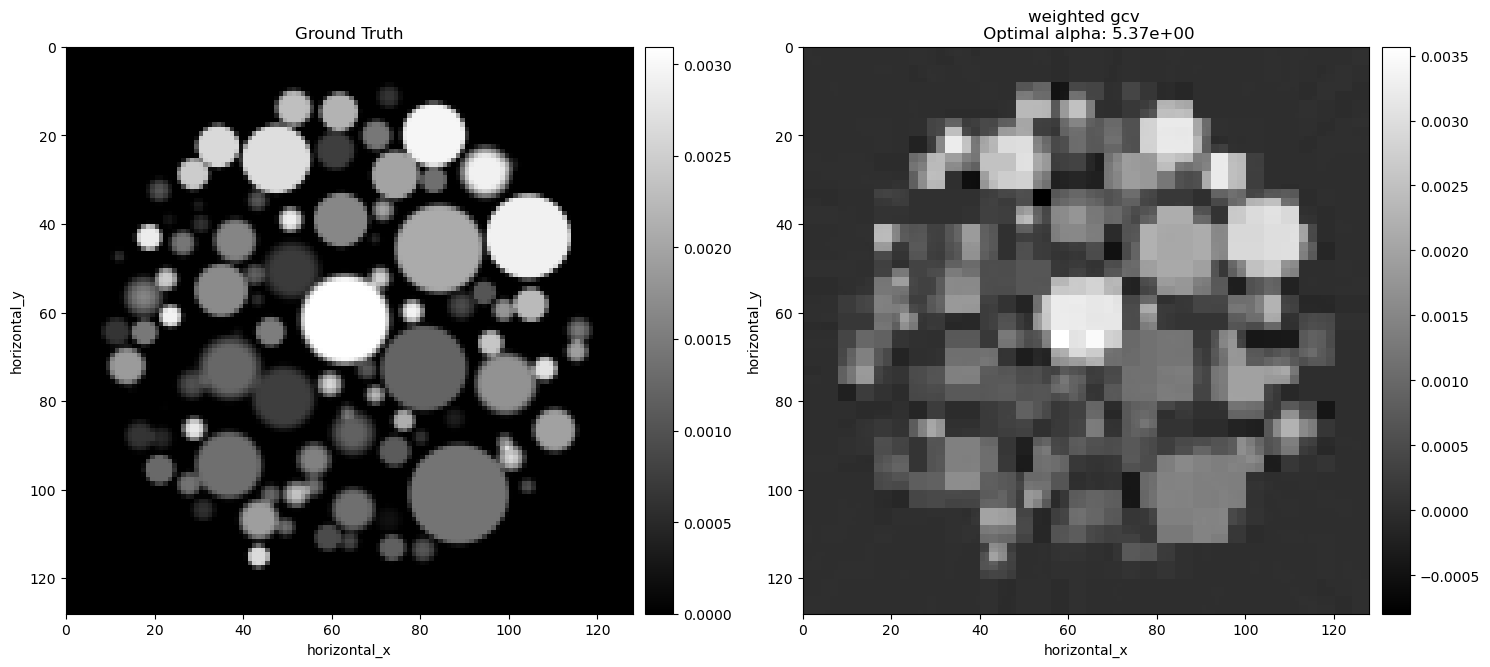

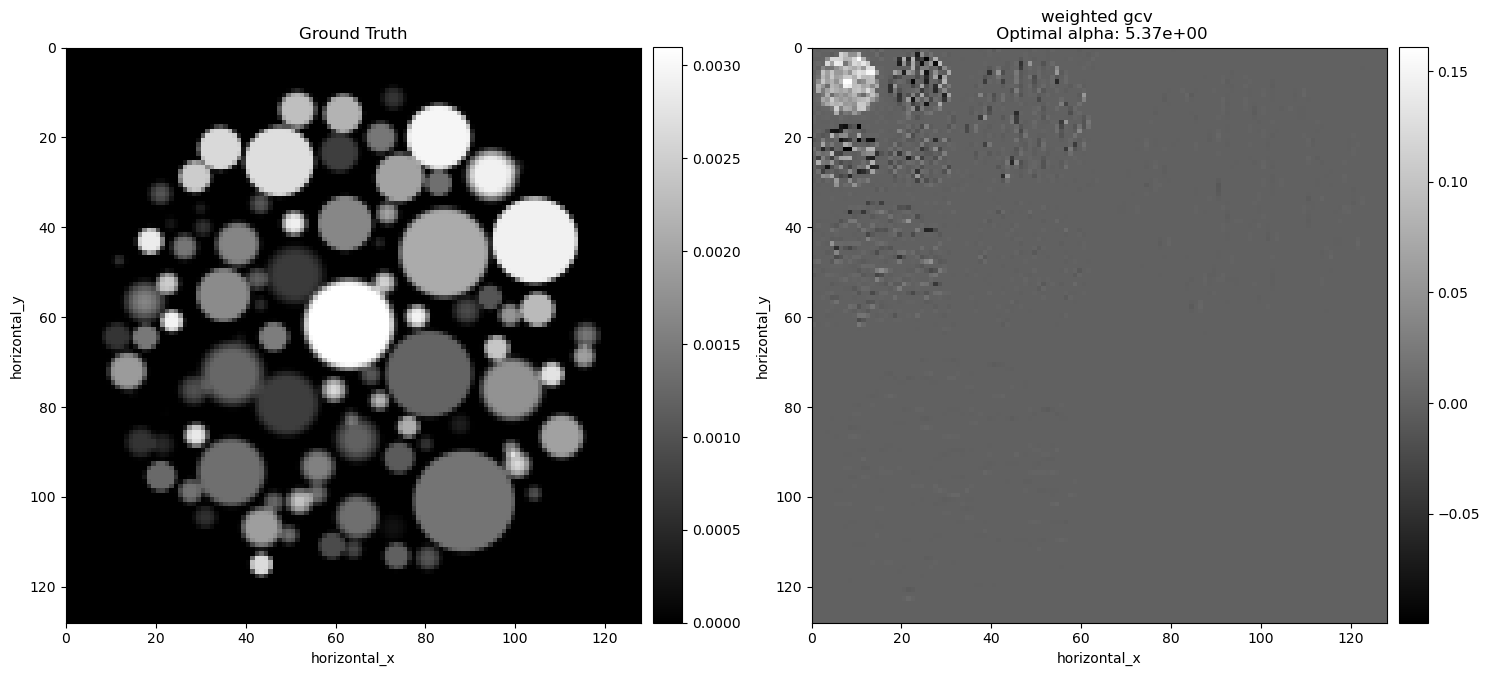

In [24]:
results_and_rerun(hybridlsqrwgcv)

## 4. Adaptive-Weighted GCV Rule

In [25]:
awgcv_rule = UpdateRegGCV(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                gcv_weight=0.7,
                                adaptive_weight=True)

hybridlsqrawgcv = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                              struct_operator=W, max_inner_iterations=max_inner_iterations,
                         reg_norm_type=norm_type, hybrid_reg_rule=awgcv_rule)
t_start = time()
hybridlsqrawgcv.run(maxit, verbose=True)
t_end = time()
print(f"Adaptive WGCV rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

Adaptive WGCV rule took 1.863875150680542 seconds.


The optimal parameter it finds is 7.225695007953663 in 5 iterations


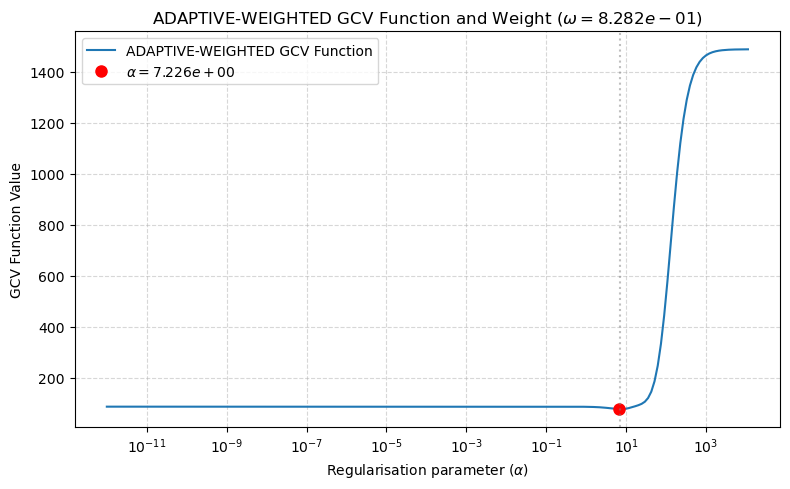

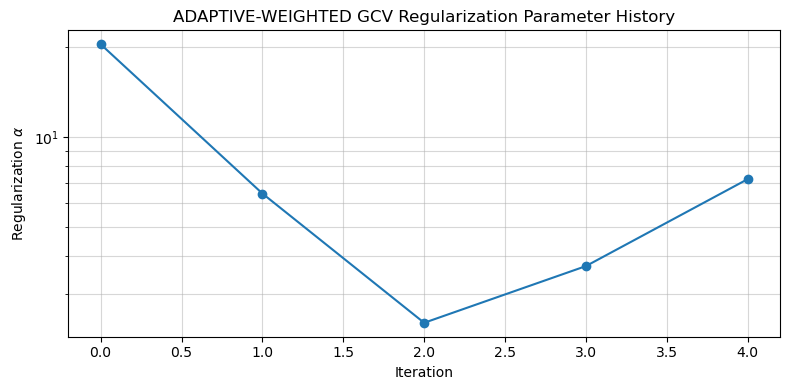

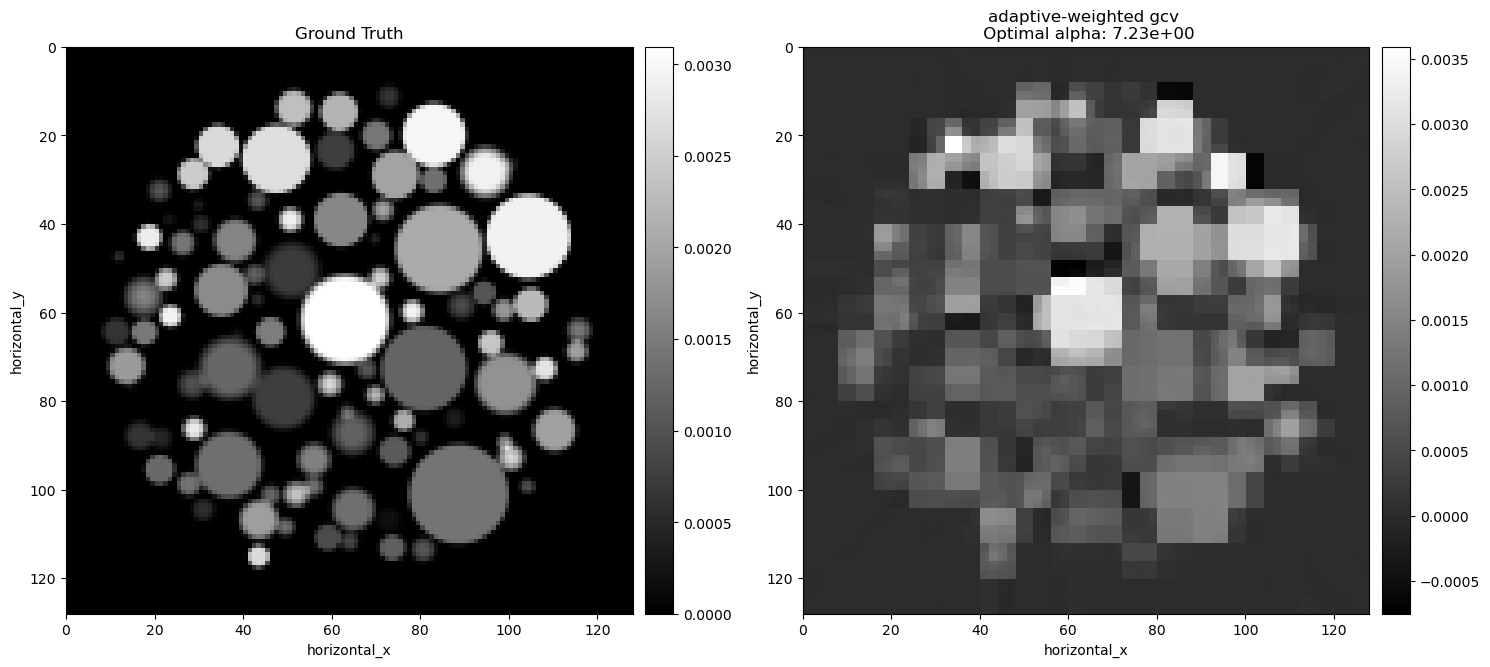

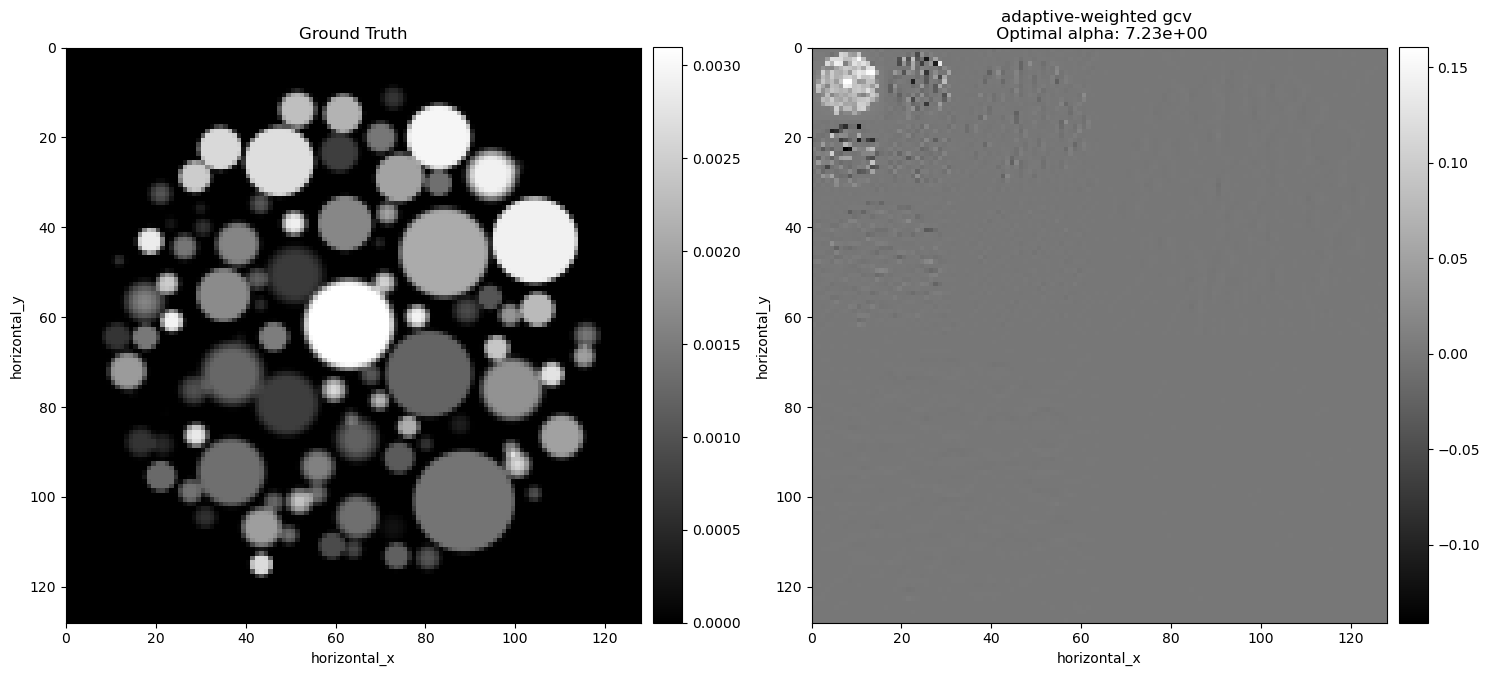

  0%|          | 0/5 [00:00<?, ?it/s]

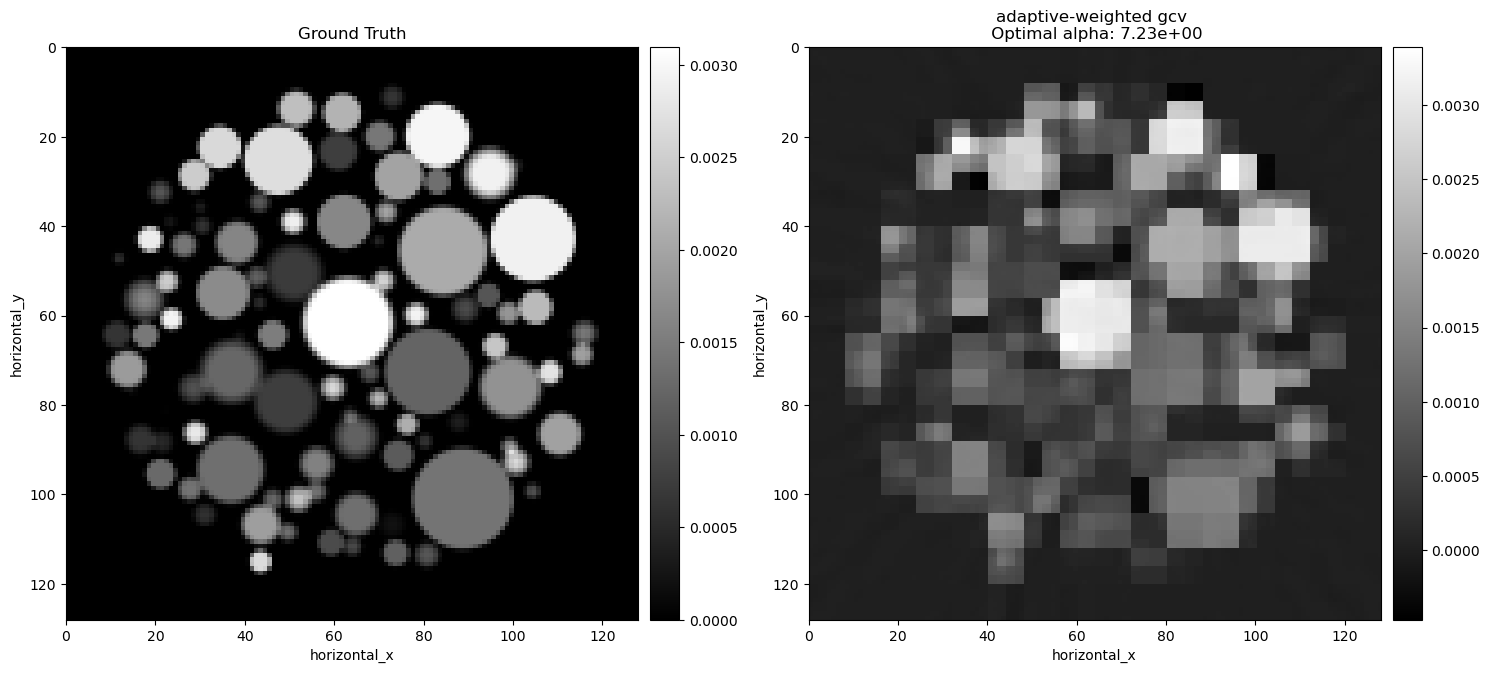

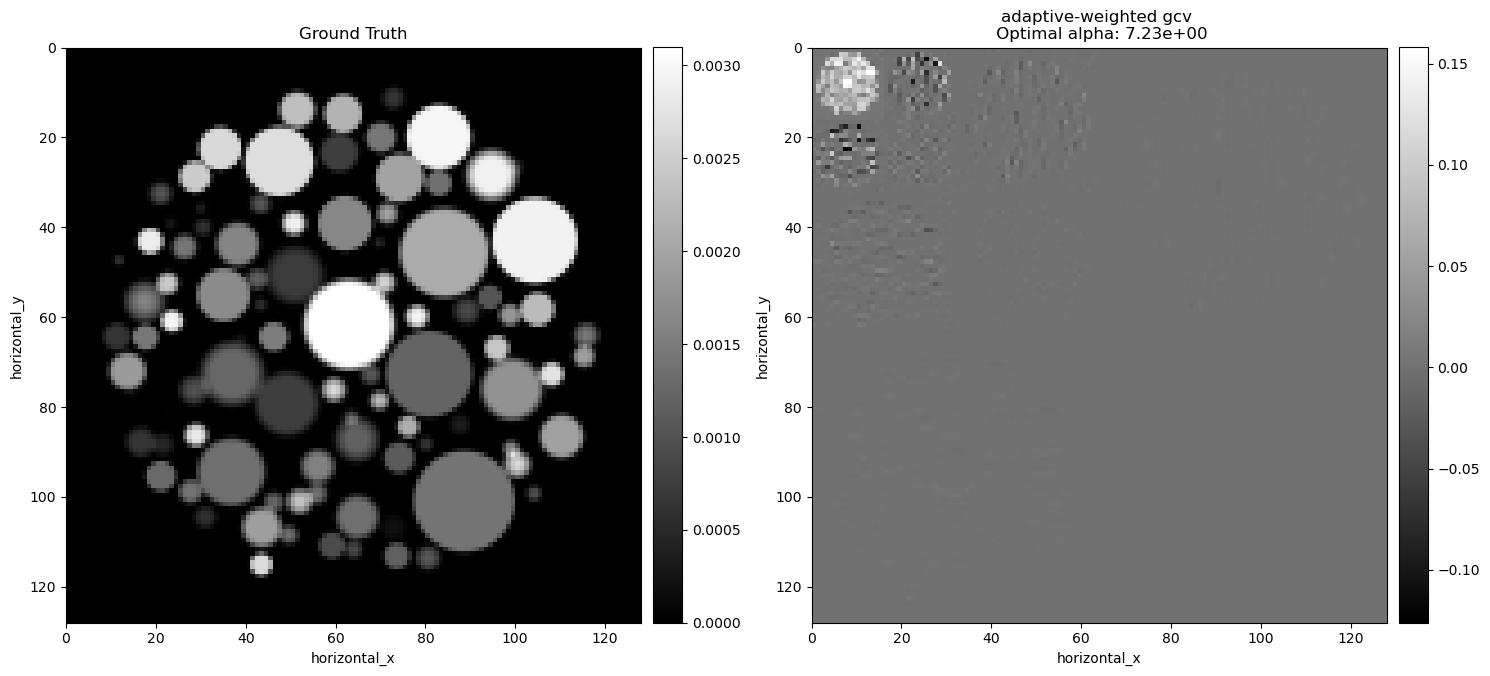

In [26]:
results_and_rerun(hybridlsqrawgcv)

## 5. Reginska Rule

In [27]:
reginska_rule = UpdateRegReginska(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                mu=0.5)

hybridlsqrreginska = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                                 struct_operator=W, max_inner_iterations=max_inner_iterations,
                         reg_norm_type=norm_type, hybrid_reg_rule=reginska_rule)
t_start = time()
hybridlsqrreginska.run(maxit, verbose=True)
t_end = time()
print(f"Reginska rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

Reginska rule took 39.83530044555664 seconds.


The optimal parameter it finds is 0.5321889366809818 in 10 iterations


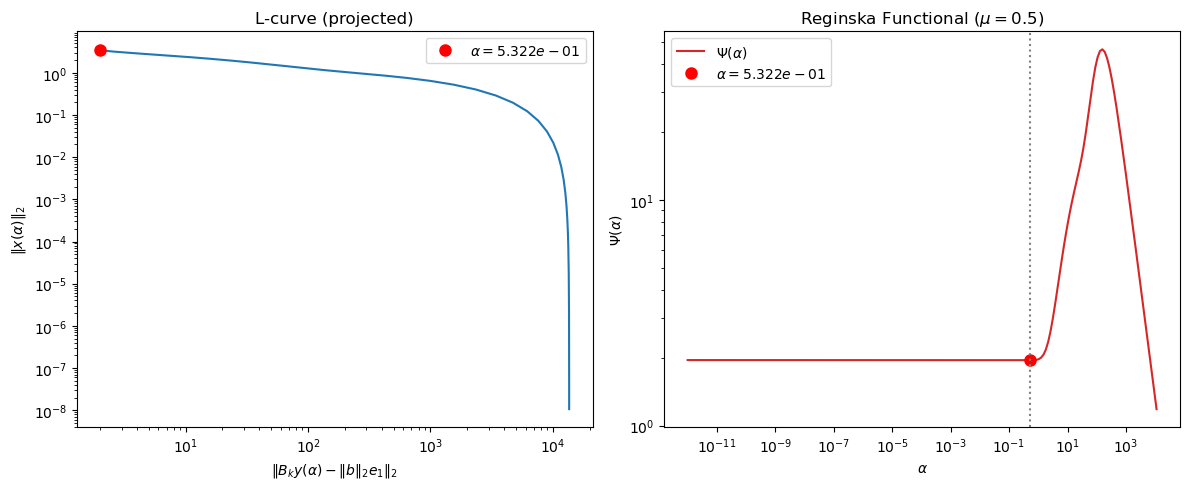

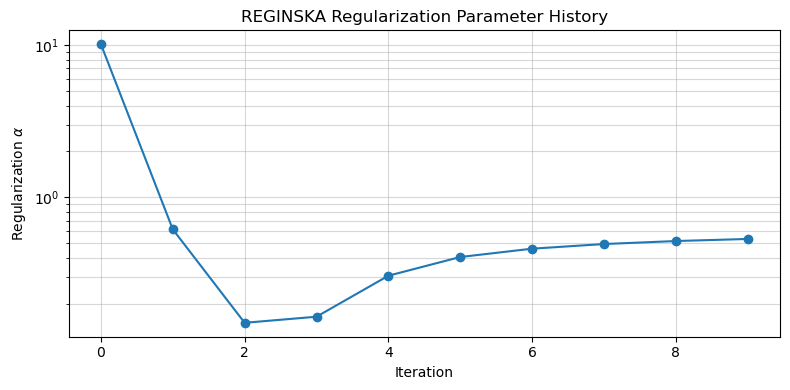

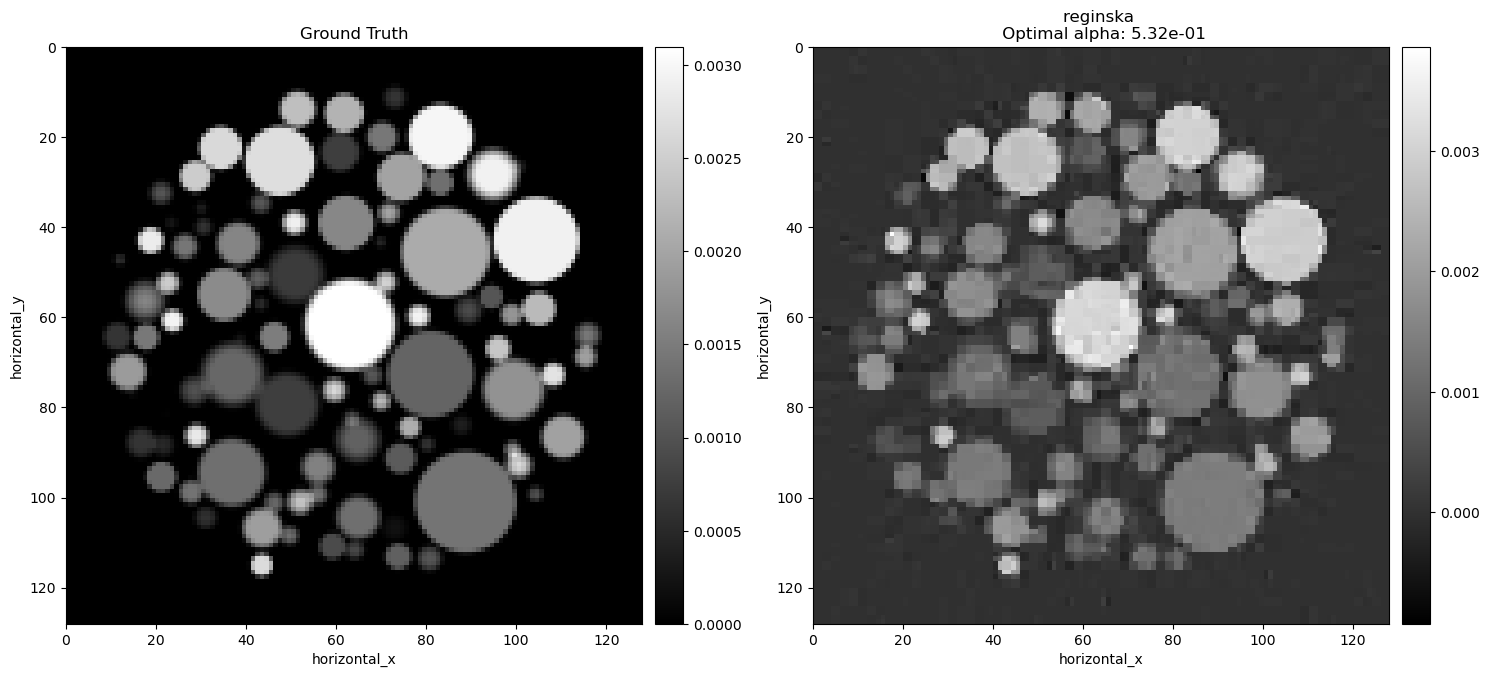

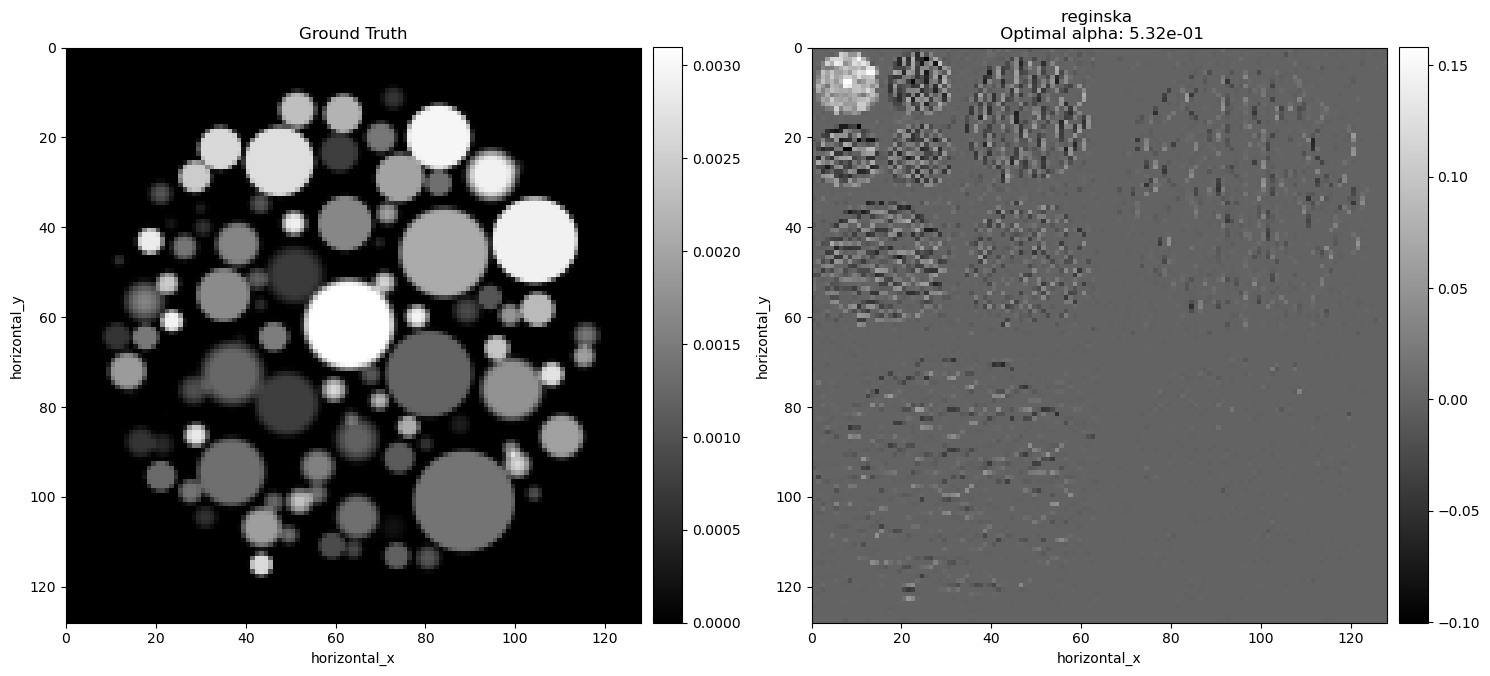

  0%|          | 0/10 [00:00<?, ?it/s]

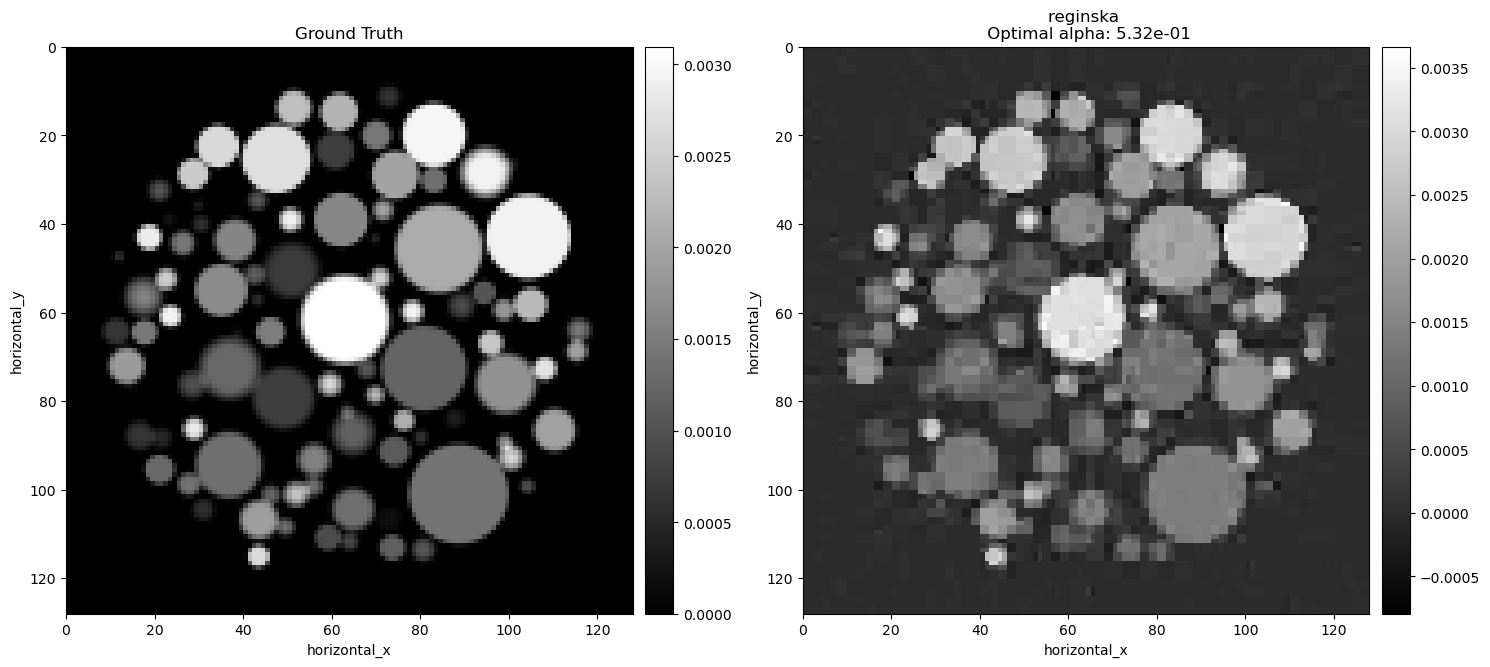

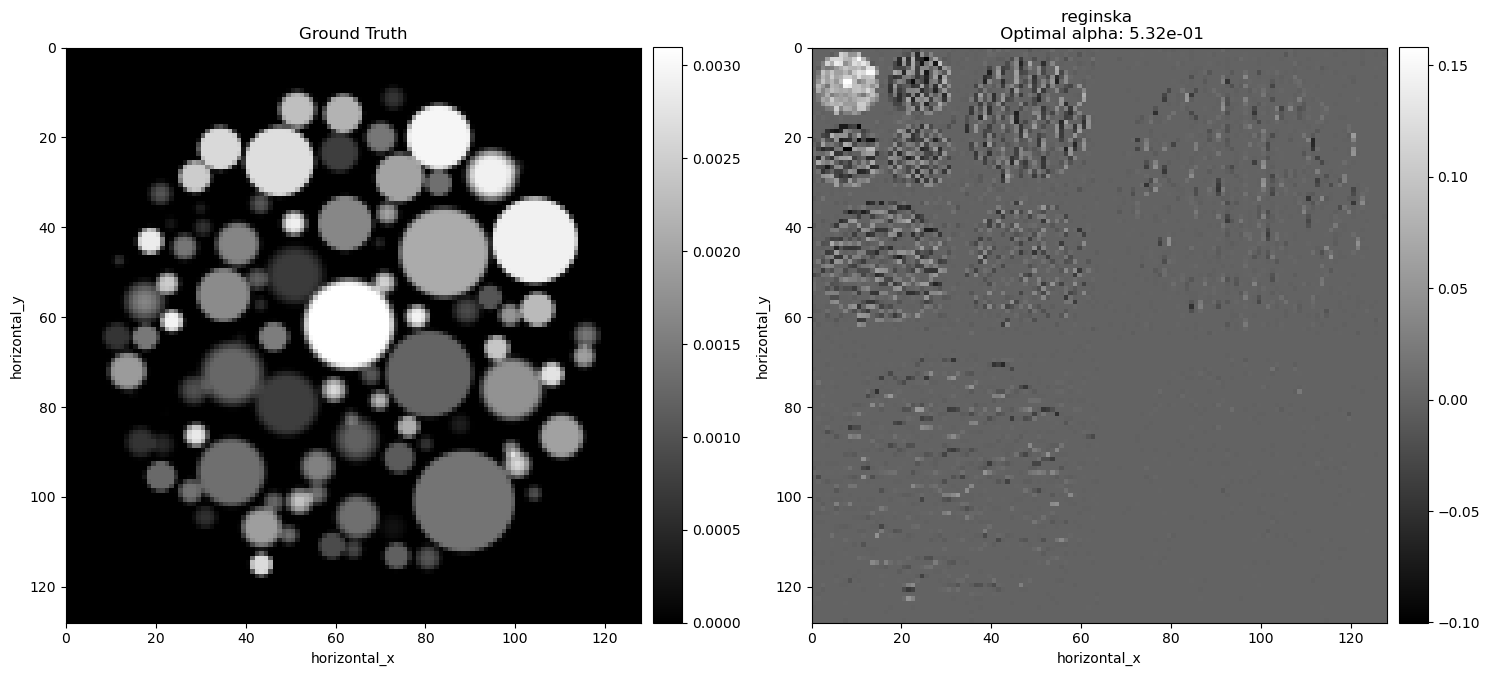

In [28]:
results_and_rerun(hybridlsqrreginska)

## 5. UPRE Rule

In [29]:
upre_rule = UpdateRegUPRE(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                noise_variance=noisevariance)

hybridlsqrupre = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                             struct_operator=W, max_inner_iterations=max_inner_iterations,
                         reg_norm_type=norm_type, hybrid_reg_rule=upre_rule)
t_start = time()
hybridlsqrupre.run(maxit, verbose=True)
t_end = time()
print(f"UPRE rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

UPRE rule took 2.1875364780426025 seconds.


The optimal parameter it finds is 0.11166037885140481 in 10 iterations


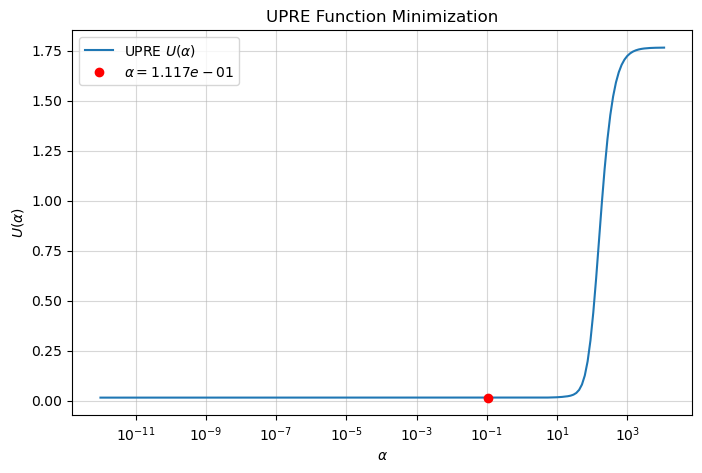

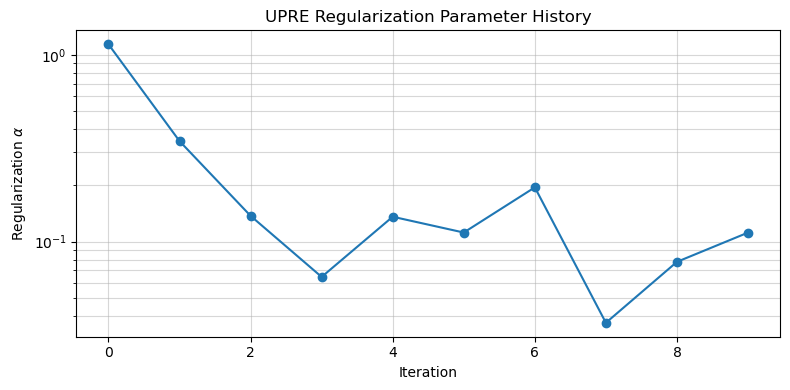

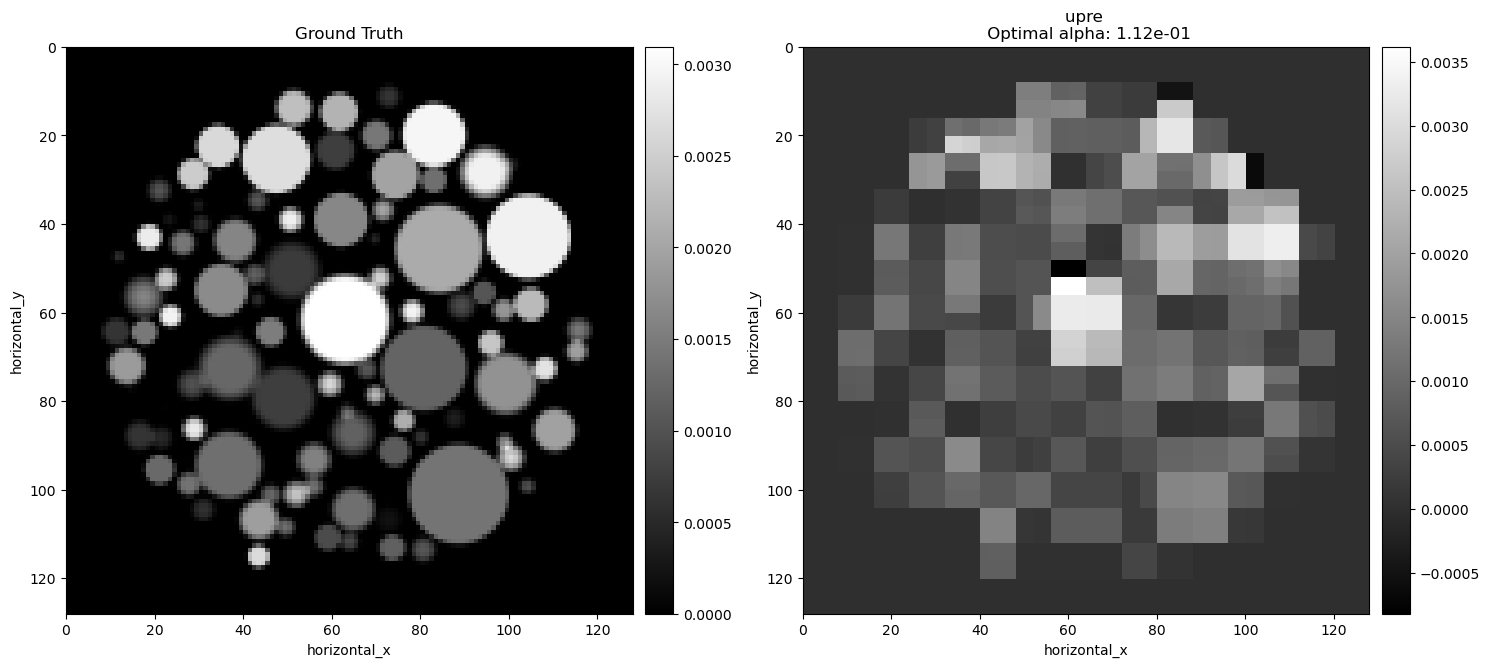

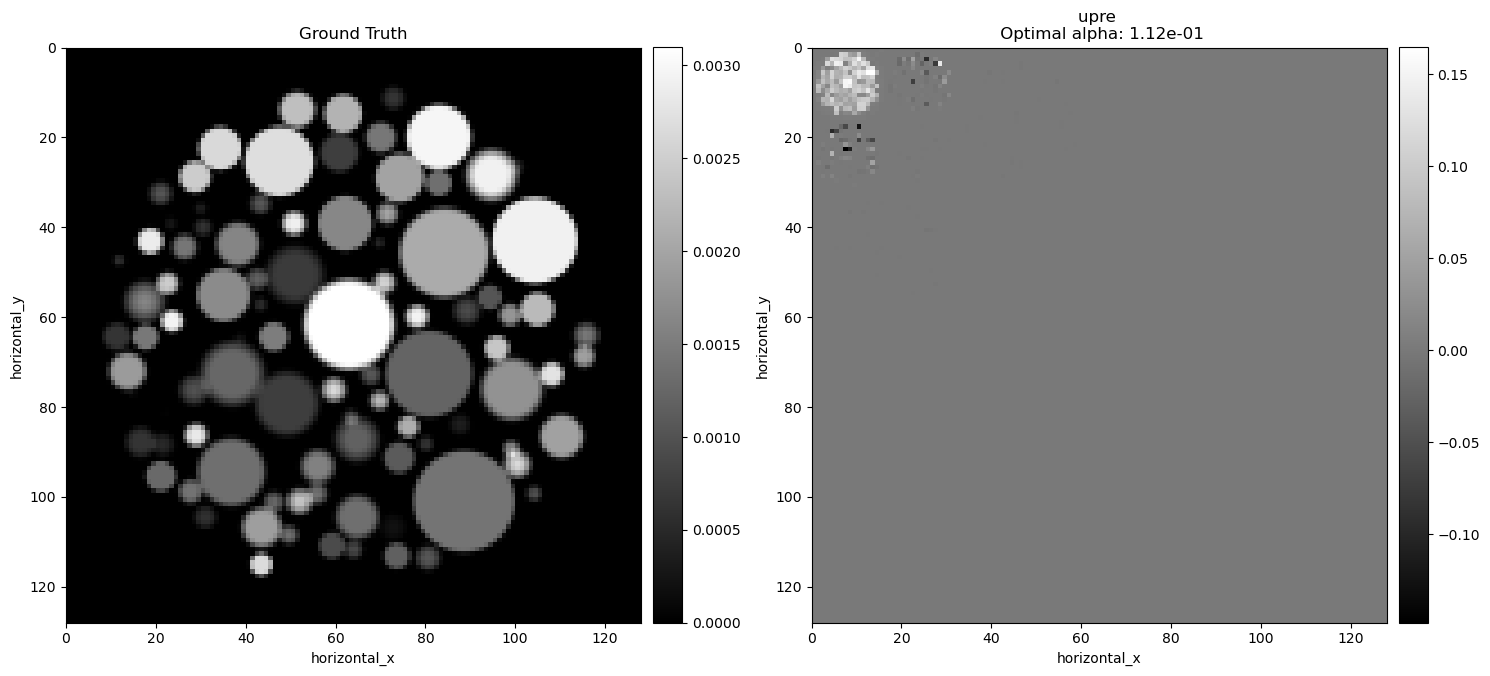

  0%|          | 0/10 [00:00<?, ?it/s]

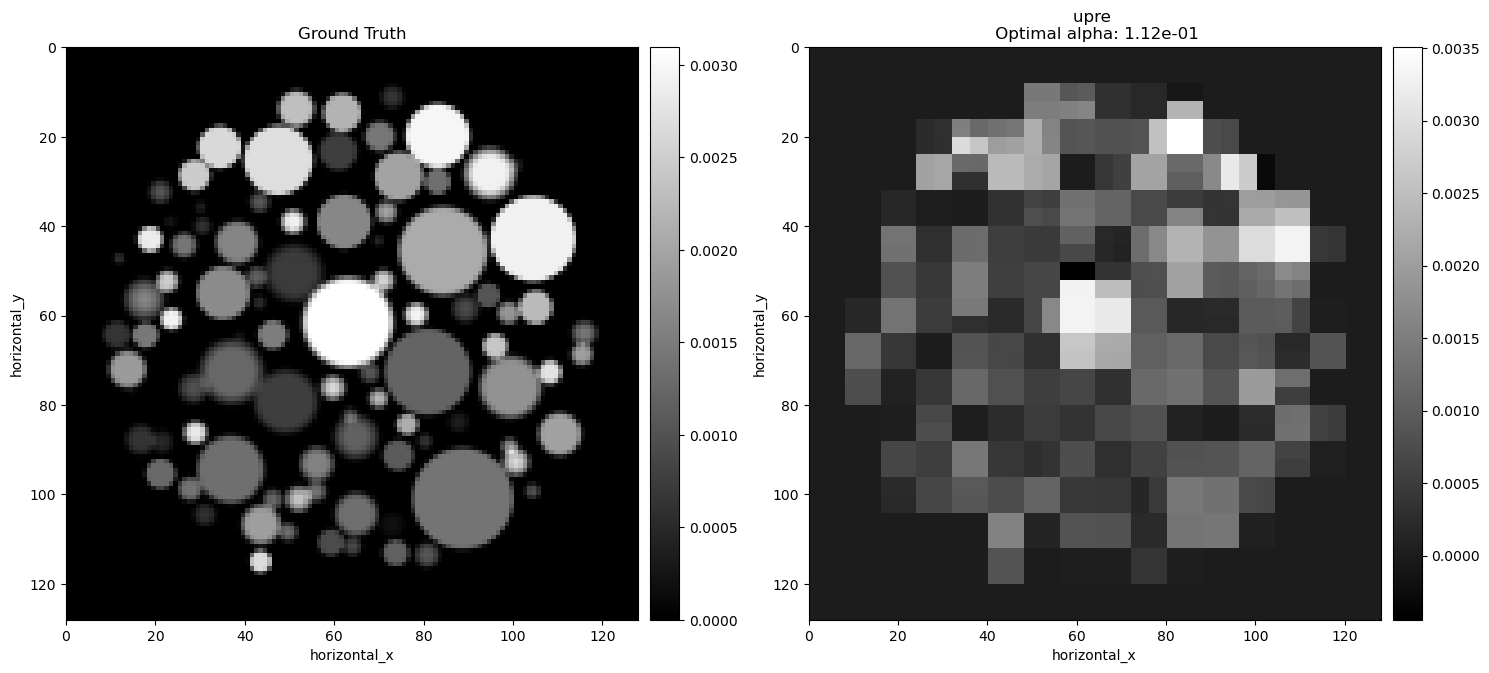

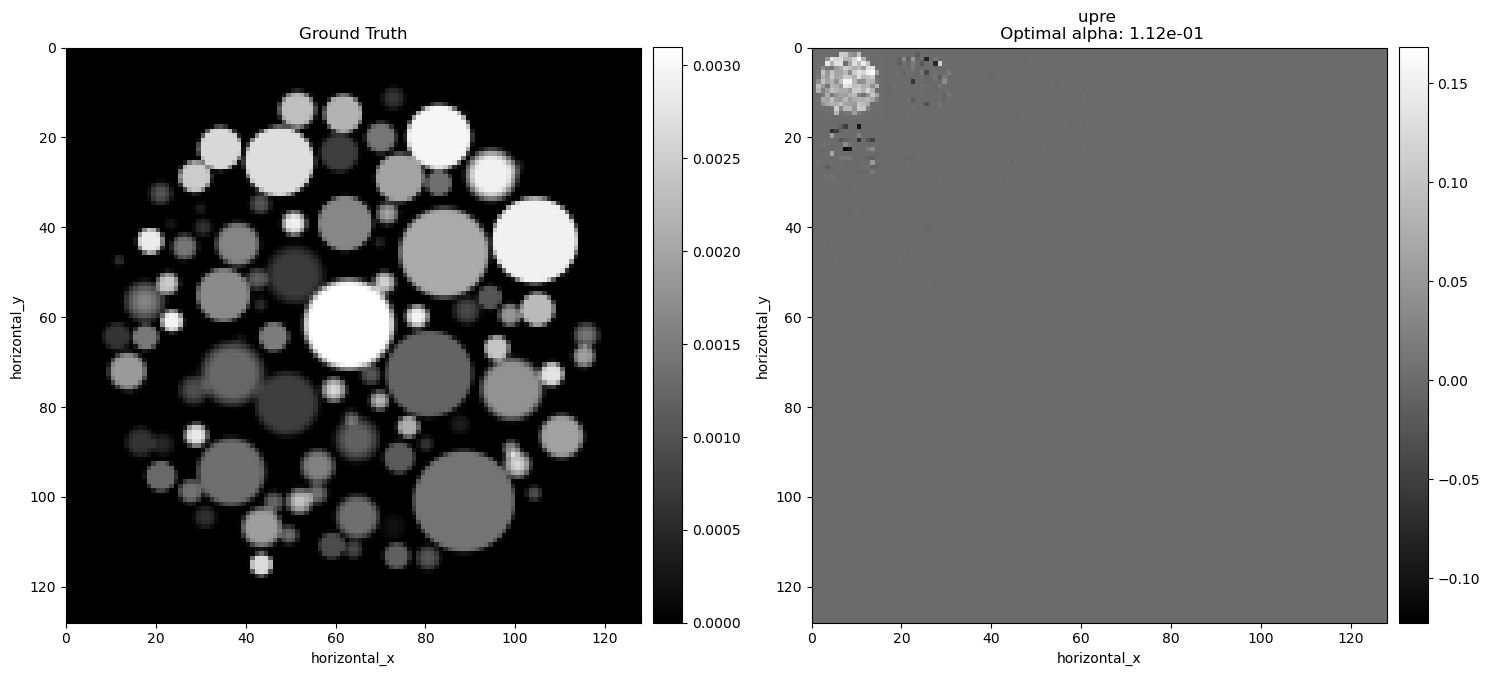

In [30]:
results_and_rerun(hybridlsqrupre)

## 7. L-curve Rule

In [31]:
lcurve_rule = UpdateRegLcurve(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol)

hybridlsqrlcurve = HybridGLSQR(operator=A, data=data, initial=initial, xtol=xtol,
                           struct_operator=W, max_inner_iterations=max_inner_iterations,
                         reg_norm_type=norm_type, hybrid_reg_rule=lcurve_rule)
t_start = time()
hybridlsqrlcurve.run(maxit, verbose=True)
t_end = time()
print(f"L-curve rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

L-curve rule took 41.65502667427063 seconds.


The optimal parameter it finds is 0.12477600692926519 in 10 iterations


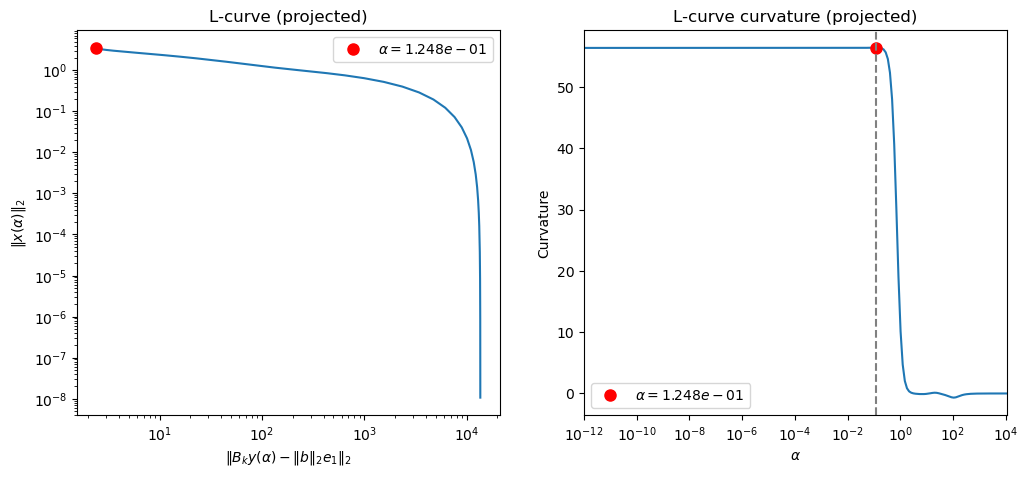

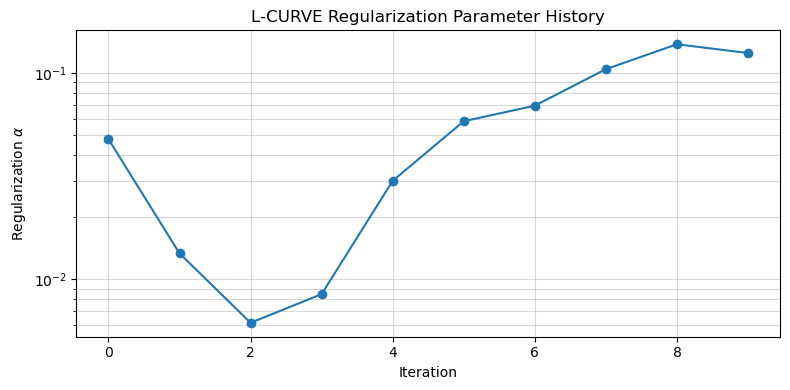

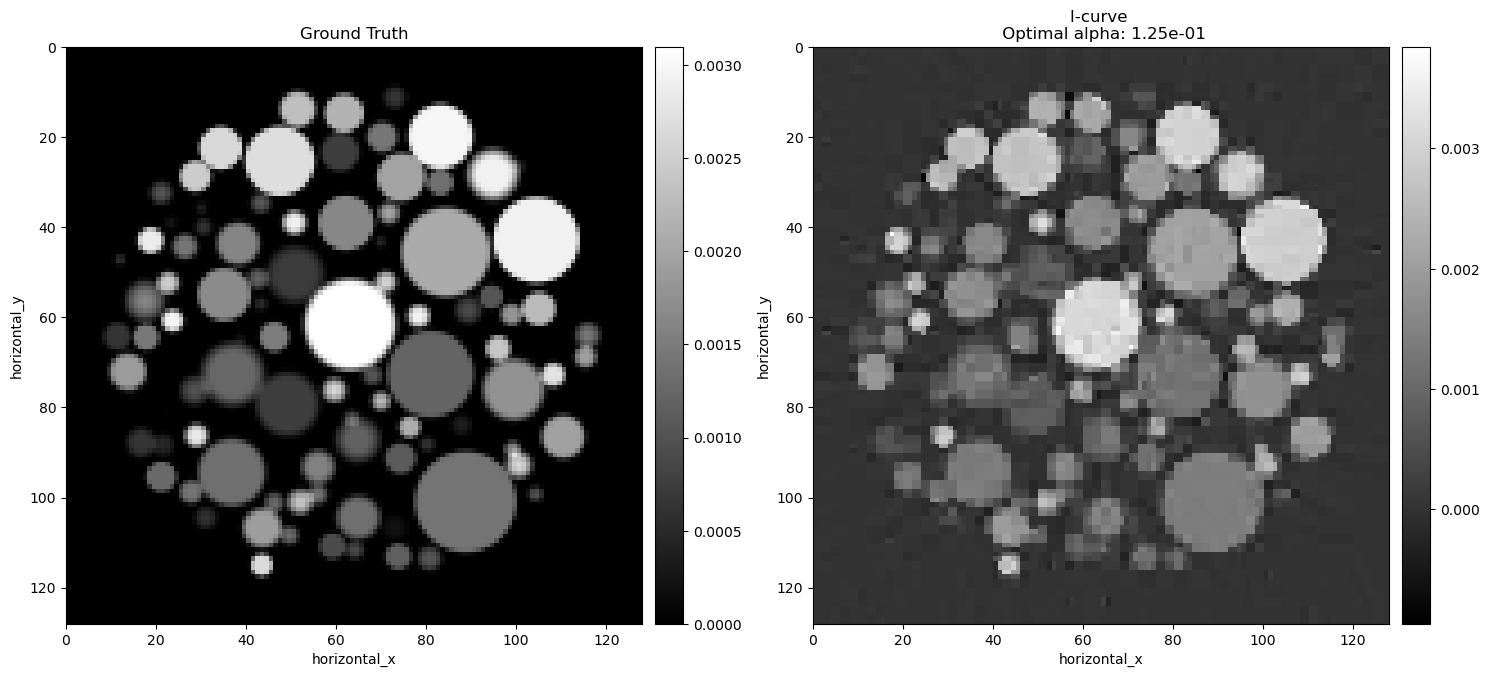

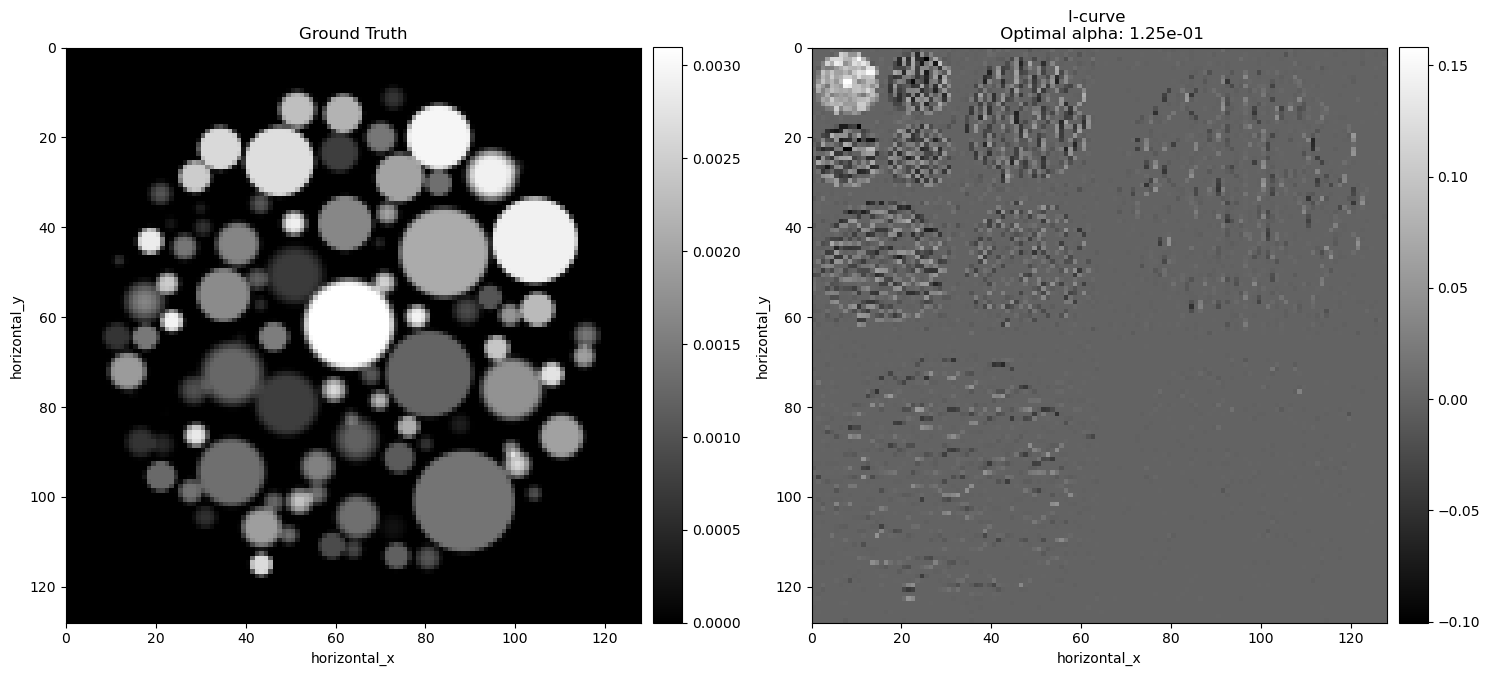

  0%|          | 0/10 [00:00<?, ?it/s]

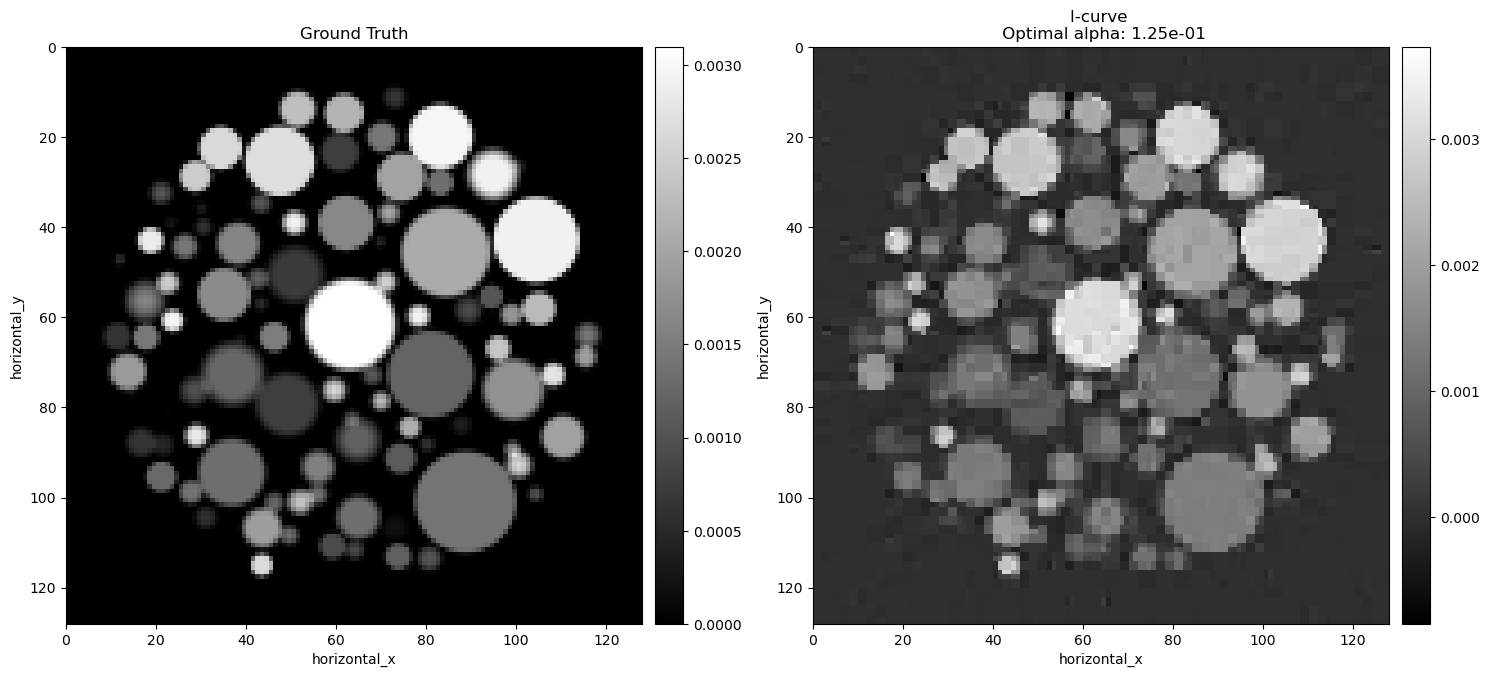

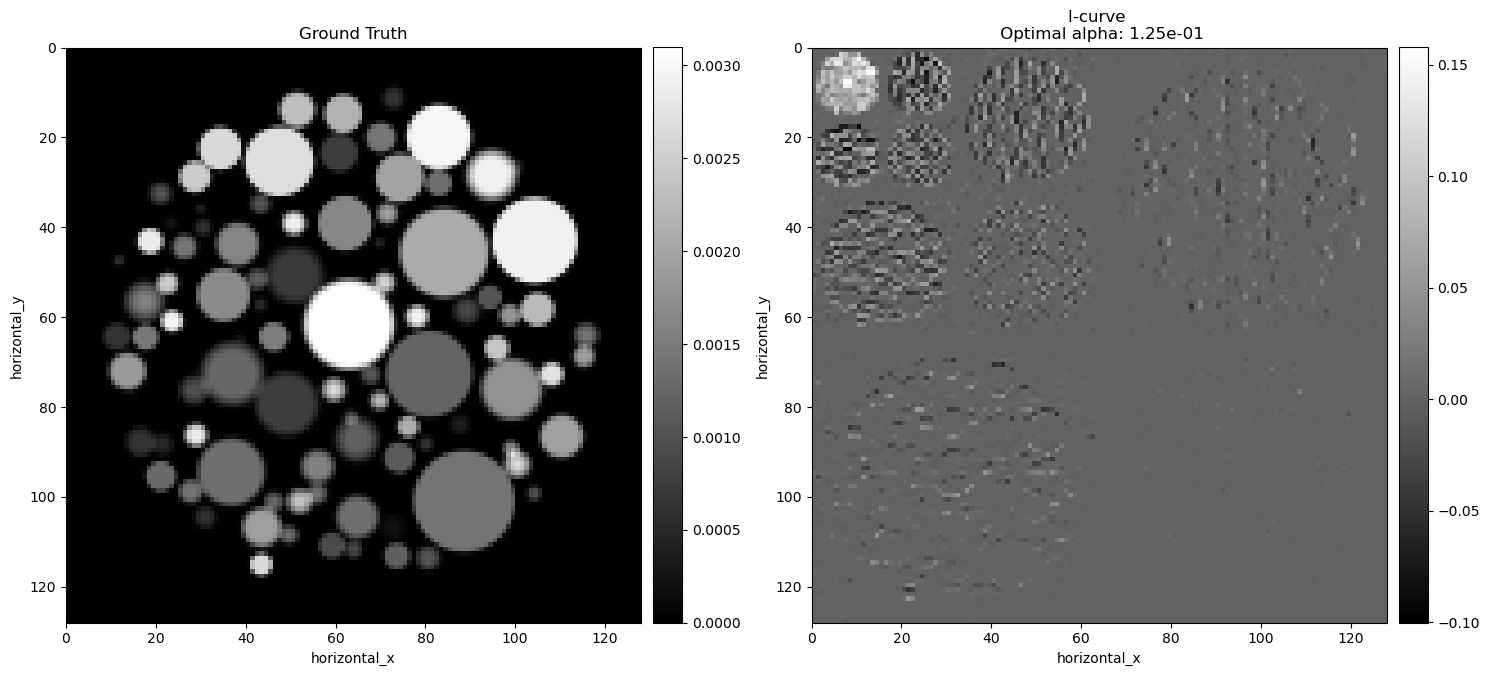

In [32]:
results_and_rerun(hybridlsqrlcurve)